# EvaluateOnlyOnValidation.ipynb

Evaluation of the model on unseen data.

Produces Figure 7b and spatial scatter maps for Figure 7c.

In [1]:
import dgl
import torch
import numpy as np
import pandas as pd
import pickle as pk
import anndata as ad
from torch import nn
from sklearn.neighbors import KDTree
from scipy.spatial.distance import cdist
from dgl.data import DGLDataset
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import summary
from dgl.dataloading import GraphDataLoader
from pytorch_metric_learning import losses, miners, reducers, distances
import sklearn
import scanpy as sc
import anndata as ad
from sklearn.metrics.pairwise import cosine_similarity
from pytorch_metric_learning import losses, miners, reducers, distances

from dgl.nn.pytorch import GATConv, SumPooling, AvgPooling, MaxPooling
from dgl.nn import GraphConv, SAGEConv
from torch_geometric.nn import TransformerConv, global_mean_pool, global_max_pool

import torch
import torch.nn.functional as F
from torch_geometric.utils import k_hop_subgraph
import networkx as nx
import dash
import dash_cytoscape as cyto
from dash import html, dcc
from dash.dependencies import Input, Output

from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors

import seaborn as sns

class GraphTransformerModel(nn.Module):
    def __init__(self, input_dim, edge_dim, hidden_dim, num_classes, num_layers=4, heads=4, dropout=0.1):
        super(GraphTransformerModel, self).__init__()
        self.input_dim = input_dim
        self.edge_dim = edge_dim
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.dropout = dropout
        edge_hidden_dim = 1

        # Input projection for node features
        self.node_embedding = nn.Linear(input_dim, hidden_dim)
        self.edge_embedding = nn.Linear(edge_dim, edge_hidden_dim)

        # Transformer layers
        self.transformer_layers = nn.ModuleList([
            TransformerConv(input_dim + hidden_dim, hidden_dim, heads=heads, dropout=dropout, edge_dim=edge_hidden_dim)
        ])
        for _ in range(num_layers):
            self.transformer_layers.append(TransformerConv(input_dim + (hidden_dim)*heads, hidden_dim, heads=heads, dropout=dropout, edge_dim=edge_hidden_dim))

        # Global pooling
        self.global_pooling = global_mean_pool

        # Output layer
        self.output_layer = nn.Linear((hidden_dim)*heads, num_classes)

    def forward(self, x, edge_index, edge_attr, batch):
        """
        x: Node features [num_nodes, input_dim]
        edge_index: Graph connectivity [2, num_edges]
        edge_attr: Edge features [num_edges, edge_dim]
        batch: Batch vector [num_nodes] mapping nodes to graphs
        """
        imp_emb = x

        # Embed node and edge features
        x = self.node_embedding(x)  # [num_nodes, hidden_dim]
        x = F.sigmoid(x)
        edge_attr = self.edge_embedding(edge_attr)  # [num_edges, hidden_dim]
        edge_attr = F.sigmoid(edge_attr)

        # Apply transformer layers
        for i, transformer in enumerate(self.transformer_layers):
            x = transformer(torch.concat([x, imp_emb], axis=-1), edge_index, edge_attr)
            x = F.sigmoid(x)  # Apply non-linearity
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Global pooling for graph classification
        x = self.global_pooling(x, batch)  # [num_graphs, hidden_dim]
        x = self.output_layer(x)  # [num_graphs, num_classes]

        return x

model = GraphTransformerModel(input_dim=39, edge_dim=1, hidden_dim=39, num_classes=1, num_layers=2, heads=1, dropout=0.1)

/home/akilgall/miniconda3/envs/dgl_cuda_cox_new/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adataClinical = ad.read_h5ad(r'../adjTMA_cleangmm.h5ad')

/home/akilgall/miniconda3/envs/dgl_cuda_cox_new/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [3]:
adataClinical

AnnData object with n_obs × n_vars = 1187511 × 48
    obs: 'Image', 'Object ID', 'Name', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy', 'unique_core', 'patientID', 'adjtma_PCF_repA', 'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'TNM', 'stage', 'PathwayCode', 'Histology', 'Sex', 'Smoking', 'EndCycle', 'DOB', 'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse', 'Date of relapse', 'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'tregion', 'tumourdist', 'Tumour_area', 'Tumour_pc', 'Stroma_area', 'Stroma_pc', 'CT_final', 'CT_basetumour', 'base_celltypes', 'batch', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'Ki67_pos', 'G6PD_pos', 'pNRF2_pos', 'ATPA5_pos', 'GLUT1_pos', 'Hexokinase1_pos', 'ASCT2_pos', 'SDHA_pos'

In [4]:
adataClinical.obs[['Relapse_followup', "Surv_Followup"]]

,Relapse_followup,Surv_Followup
0,1968,1968.0
1,1968,1968.0
2,1968,1968.0
3,1968,1968.0
4,1968,1968.0
...,...,...
1187506,416,530.0
1187507,416,530.0
1187508,416,530.0
1187509,416,530.0


In [6]:
#model = torch.load('anomalous.pt')
model = torch.load('meta_learnRelapse_GraphTransformerNet_PoissonAug_Mar2nd2025_trainIds.pt', weights_only=False)

In [8]:
model.load_state_dict(torch.load('meta_learnRelapse_GraphTransformerNet_PoissonAug_Mar2nd2025_trainIds_dict.pt', weights_only=True))

<All keys matched successfully>

In [10]:
model

GraphTransformerModel(
  (node_embedding): Linear(in_features=56, out_features=28, bias=True)
  (edge_embedding): Linear(in_features=1, out_features=1, bias=True)
  (transformer_layers): ModuleList(
    (0-2): 3 x TransformerConv(84, 28, heads=1)
  )
  (output_layer): Linear(in_features=28, out_features=1, bias=True)
)

In [ ]:
df = adataClinical.obs[['CT_final', 'x', 'y', 'unique_core', 'Relapse', 'Relapse_status', 'Relapse_followup', 'Surv_status', 'Surv_Followup', 
       'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'pd1_median_pos', 
       'Ki67_pos', 'G6PD_pos', 'pNRF2_pos', 'pdl1_median_pos',
       'ATPA5_pos', 'GLUT1_pos', 'Hexokinase1_pos', 'ASCT2_pos', 'SDHA_pos',
       'CPT1A_pos', 'CITRATE_SYNTHASE_pos', 'protein_exp_nb', 'Hypoxic',
       'OxPhos', 'Mitochondrial', 'Oxidative_Stress', 'Lipid_Oxidation', 'PPP',
       'Glutamine_import']]

trainIds = ['TMA_A_A2', 'TMA_A_A5', 'TMA_A_A6', 'TMA_A_C1', 'TMA_A_C6', 'TMA_A_C7', 'TMA_A_E4', 'TMA_A_E6', 'TMA_A_E7', 'TMA_A_G2', 'TMA_A_G5', 'TMA_A_G6', 'TMA_A_G7', 'TMA_A_I7', 'TMA_B_A1', 'TMA_B_A2', 'TMA_B_A6', 'TMA_B_C3', 
            'TMA_B_C7', 'TMA_B_E5', 'TMA_B_G5', 'TMA_B_G6', 'TMA_B_I2', 'TMA_B_I3', 'TMA_A_B3', 'TMA_A_B4', 'TMA_A_B7', 'TMA_A_D5', 'TMA_A_F1', 'TMA_A_F3', 'TMA_A_F5', 'TMA_A_H1', 'TMA_A_J2', 'TMA_A_J4', 'TMA_A_J5', 'TMA_A_J6', 
            'TMA_B_B8', 'TMA_B_D1', 'TMA_B_D2', 'TMA_B_D6', 'TMA_B_D8', 'TMA_B_F2', 'TMA_B_F3', 'TMA_B_F4', 'TMA_B_F8', 'TMA_B_H4', 'TMA_B_H7', 'TMA_B_J7', 'TMA_A_C2', 'TMA_A_C3', 'TMA_B_D4', 'TMA_B_C5', 'TMA_B_G1', 'TMA_B_G3', 
            'TMA_B_I8',]

In [73]:
pd.Series(adataClinical.obs['unique_core'].unique())[~pd.Series(adataClinical.obs['unique_core'].unique()).isin(trainIds)].shape

(55,)

In [74]:
len(trainIds)

55

In [75]:
df

,CT_final,x,y,unique_core,Relapse,Relapse_status,Relapse_followup,Surv_status,Surv_Followup,HLA-DR_pos,...,CPT1A_pos,CITRATE_SYNTHASE_pos,protein_exp_nb,Hypoxic,OxPhos,Mitochondrial,Oxidative_Stress,Lipid_Oxidation,PPP,Glutamine_import
0,Tumour,2276.4,1257.7,TMA_A_A1,No,0.0,1968,0.0,1968.0,HLA-DR_neg,...,neg,CITRATE_SYNTHASE+,Oxphos,False,False,False,False,False,True,False
1,Tumour,2254.4,1261.8,TMA_A_A1,No,0.0,1968,0.0,1968.0,HLA-DR_neg,...,neg,neg,Oxphos,False,False,False,False,False,True,True
2,Tumour,2234.1,1265.9,TMA_A_A1,No,0.0,1968,0.0,1968.0,HLA-DR_neg,...,neg,CITRATE_SYNTHASE+,low,False,False,False,False,False,True,False
3,CD4_cells,2315.7,1273.0,TMA_A_A1,No,0.0,1968,0.0,1968.0,HLA-DR_neg,...,neg,CITRATE_SYNTHASE+,low,False,False,False,False,False,True,False
4,Tumour,2235.7,1276.6,TMA_A_A1,No,0.0,1968,0.0,1968.0,HLA-DR_neg,...,neg,CITRATE_SYNTHASE+,low,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1187506,Fibroblast,15794.7,25948.8,TMA_B_J8,Yes,1.0,416,1.0,530.0,HLA-DR_neg,...,CPT1A+,neg,Glutamineimport_PPP,False,False,False,False,True,True,False
1187507,Tumour,15808.1,25947.6,TMA_B_J8,Yes,1.0,416,1.0,530.0,HLA-DR_neg,...,neg,neg,Glutamineimport_PPP,False,False,False,False,False,True,False
1187508,Tumour,15816.2,25947.9,TMA_B_J8,Yes,1.0,416,1.0,530.0,HLA-DR_neg,...,neg,neg,Glutamineimport_PPP,False,False,False,False,False,True,False
1187509,CD8_cells,15825.7,25947.6,TMA_B_J8,Yes,1.0,416,1.0,530.0,HLA-DR_neg,...,CPT1A+,neg,Glutamineimport_PPP,False,False,False,False,True,True,False


In [4]:
ct_cols = ['Tumour', 'Other_Stromal_cells', 'Macrophages', 'Fibroblast',
                  'CD4_cells', 'Vessels', 'CD8_cells', 'CD44+', 'MHC_II',
                  'Macrophages_M2', 'B_cells', 'Proliferating', 'MHC_II_CD44+',
                  'MHC_I', 'MHC_I&II', 'MHC_I_CD44+', 'Proliferating_MHC_I',
                  'Macrophages_M2_PDL1+', 'Macrophages_PDL1+',
                  'MHC_I&II_CD44+', 'PDL1_MHC_I&II', 'CD44+_PDL1+',
                  'Proliferating_CD44+', 'CD4_TFH', 'PDL1+', 'PD1+_CD8_cells',
                  'Cytotoxic_CD8_cells', 'PDL1_MHC_I', 'Proliferating_PDL1',
                  'PDL1_MHC_II', 'Proliferating_MHC_II', 'PDL1_MHC_I&II_CD44+',
                  'Proliferating_MHC_I&II', 'PDL1_MHC_I_CD44+']
functional_cols = ['pdl1_median_pos',
                     'pd1_median_pos',
                     'HLA-DR_pos',
                     'HLA-A_pos',
                     'ICOS(CD278)_pos',
                     'Ki67_pos',
                     'G6PD_pos',
                     'pNRF2_pos',
                     'ATPA5_pos',
                     'GLUT1_pos',
                     'Hexokinase1_pos',
                     'ASCT2_pos',
                     'SDHA_pos',
                     'CPT1A_pos',
                     'CITRATE_SYNTHASE_pos',
                     'Hypoxic',
                     'OxPhos',
                     'Mitochondrial',
                     'Oxidative_Stress',
                     'Lipid_Oxidation',
                     'PPP',
                     'Glutamine_import']

# For plotting
mini_functional_cols = ['pdl1_median_pos',
                     'pd1_median_pos',
                     'HLA-DR_pos',
                     'HLA-A_pos',
                     'ICOS(CD278)_pos',
                     'Ki67_pos',
                     'Hypoxic',
                     'OxPhos',
                     'Mitochondrial',
                     'Oxidative_Stress',
                     'Lipid_Oxidation',
                     'PPP',
                     'Glutamine_import']
marker_cols = ct_cols + functional_cols

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [78]:
df_orig = pd.read_csv(r'graphData_adjTMA.csv')

/tmp/ipykernel_3268/208254551.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_orig = pd.read_csv(r'graphData_adjTMA.csv')


# Traditional Evaluation

In [79]:
def returnKNNNeighbors(ndf, xcol, ycol, rad):
    edges, distances = [], []
    points = np.array([[a, b] for a, b in zip(ndf[xcol].to_numpy(), ndf[ycol].to_numpy()) ])
    
    tree = KDTree(points, leaf_size=2)
    all_nn_indices = tree.query_radius(points, r=rad)

    cdists = cdist(points, points)

    for i in range(len(all_nn_indices)):
        for j in range(len(all_nn_indices[i])):
            if i != all_nn_indices[i][j]:
                edges.append([i, all_nn_indices[i][j]])
                distances.append(cdists[i, all_nn_indices[i][j]])
    return np.array(edges), np.array(distances)

cell_types_cols = list(sorted(set(df['CT_final'])))

def returnGraph(patientdf, rad, extras=False):
    edges, distances = returnKNNNeighbors(patientdf, xcol='x', ycol='y', rad=rad)
    edges_data = pd.DataFrame(edges, columns=['source', 'destination'])
    edges_data['distances'] = distances#Added for WGAT

    node_features = pd.get_dummies(patientdf["CT_basetumour"]).reindex(columns=cell_types_cols, fill_value=False).astype(int).astype(float)
    node_features = pd.concat([node_features, patientdf[functional_cols]], axis=1)
    node_features = torch.from_numpy(node_features.to_numpy()).float()

    node_labels = torch.from_numpy(
        patientdf["Relapse"].values).long()#.astype("category").cat.codes.to_numpy()

    edges_src = torch.from_numpy(edges_data["source"].to_numpy())
    edges_dst = torch.from_numpy(edges_data["destination"].to_numpy())
    graph = dgl.graph(
        (edges_src, edges_dst), num_nodes=len(node_features)#patientdf.shape[0]
    )
    graph.ndata["feat"] = node_features
    graph = dgl.to_bidirected(graph, copy_ndata=True)

    graph.edata['dist'] = torch.from_numpy(edges_data["distances"].to_numpy() / 50.0).float()
   
    return graph, patientdf["Relapse"].iloc[0], [1]

    
class YTMAGraphs(DGLDataset):
    def __init__(self, patient_indices):
        self.patient_indices = patient_indices
        self.bg = None
        self.metas = None
        self.sampling_layers=1
        super().__init__(name="ytma")

    def process(self):
        self.bg, self.metas = returnBG(self.patient_indices)

    def __getitem__(self, i):
        numLayers = max(np.random.poisson(self.sampling_layers), 1)
        subgraph, _ = dgl.khop_in_subgraph(self.bg, i, numLayers)
        subgraph = graph_augmentation_pipeline(subgraph)

        return subgraph, self.bg.ndata['labels'][i], self.metas[int(self.bg.ndata['graph'][i])]+[i]

    def __len__(self):
        return self.bg.num_nodes()

def returnBG(patients):
    gS, lS, metaS = returnGraphs(patients)
    bg = dgl.batch(gS)
    return bg, metaS

def returnGraphs(patients_to_select):
    batchI, totalGraphs = 0, 0
    graphs, labels, patients_ids, metas = [], [], [], []
    for graphI, (patient_id, patdf) in enumerate(df.groupby(by='unique_core')):
        if np.isnan(patdf['Relapse'].iloc[0]) or type(patdf['Relapse'].iloc[0]) == str or \
            patdf['unique_core'].iloc[0] not in patients_to_select:
            continue

        g, l, meta = returnGraph(patdf, 80.0)
        g = dgl.add_self_loop(g, fill_data=0.0)
        g.ndata['labels'] = l*torch.ones(g.num_nodes())
        g.ndata['graph'] = totalGraphs*torch.ones(g.num_nodes())
        g.ndata['nid'] = torch.tensor(list(range(g.num_nodes())))

        graphs.append(g)
        labels.append(l)
        patients_ids.append(patient_id)
        metas.append(meta)
        totalGraphs += 1

    return graphs, labels, metas

In [80]:
inds = list(range(len(set(df['unique_core']))))

In [81]:
df.unique_core = df.unique_core.astype(str)

/tmp/ipykernel_3268/4097675140.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.unique_core = df.unique_core.astype(str)


In [82]:
def returnGraphWithXY(patientdf, types, rad):
    edges, distances = returnKNNNeighbors(patientdf, xcol='x', ycol='y', rad=rad)
    edges_data = pd.DataFrame(edges, columns=['source', 'destination'])
    edges_data['distances'] = distances/50.0

    node_features = pd.get_dummies(patientdf['CT_final']).reindex(columns=types, fill_value=False).astype(int).astype(float)
    node_features = pd.concat([node_features, patientdf[functional_cols]], axis=1)

    node_features = torch.from_numpy(node_features.to_numpy()).float()

    node_labels = torch.from_numpy(
        patientdf["Relapse"].to_numpy()).long()

    edges_src = torch.from_numpy(edges_data["source"].to_numpy())
    edges_dst = torch.from_numpy(edges_data["destination"].to_numpy())
    graph = dgl.graph(
        (edges_src, edges_dst), num_nodes=len(node_features)#patientdf.shape[0]
    )
    graph.ndata["feat"] = node_features
    graph.ndata['X'] = torch.from_numpy(patientdf['x'].to_numpy())
    graph.ndata['Y'] = torch.from_numpy(patientdf['y'].to_numpy())
    #graph.ndata['CT_final'] = torch.from_numpy(patientdf['CT_final'].to_numpy())
    if patientdf['Relapse_followup'].iloc[0] != '#VALUE!':
        graph.ndata['Relapse_followup'] = torch.from_numpy(np.array(patientdf['Relapse_followup'].to_numpy(), dtype=np.float64))
    else:
        graph.ndata['Relapse_followup'] = torch.from_numpy(np.nan*np.ones_like(np.array(patientdf['Relapse_followup'].to_numpy()), dtype=np.float64))
    graph.ndata['Relapse_status'] = torch.from_numpy(patientdf['Relapse_status'].to_numpy())
    graph.ndata['Surv_Followup'] = torch.from_numpy(patientdf['Surv_Followup'].to_numpy())
    graph.ndata['Surv_status'] = torch.from_numpy(patientdf['Surv_status'].to_numpy())
    graph = dgl.to_bidirected(graph, copy_ndata=True)

    graph.edata['dist'] = torch.from_numpy(edges_data["distances"].to_numpy()).float()

    return graph, patientdf["Relapse"].iloc[0]

In [83]:
keys = ['Relapse'] + functional_cols

def mapping(x):
    if type(x) == bool:
        return int(x)

    if not type(x) is str:
        return float(x)
        
    if 'neg' in x:
        return 0
    elif 'pos' in x or '+' in x:
        return 1
    elif 'Yes' in x:
        return 1
    elif 'No' in x:
        return 0
    else:
        print("ERROR\t", key)
        return x
    
for key in keys:
    df[key] = df[key].apply(mapping)

/tmp/ipykernel_3268/1365905016.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = df[key].apply(mapping)


In [84]:
df.keys()

Index(['CT_final', 'x', 'y', 'unique_core', 'Relapse', 'Relapse_status',
       'Relapse_followup', 'Surv_status', 'Surv_Followup', 'HLA-DR_pos',
       'HLA-A_pos', 'ICOS(CD278)_pos', 'pd1_median_pos', 'Ki67_pos',
       'G6PD_pos', 'pNRF2_pos', 'pdl1_median_pos', 'ATPA5_pos', 'GLUT1_pos',
       'Hexokinase1_pos', 'ASCT2_pos', 'SDHA_pos', 'CPT1A_pos',
       'CITRATE_SYNTHASE_pos', 'protein_exp_nb', 'Hypoxic', 'OxPhos',
       'Mitochondrial', 'Oxidative_Stress', 'Lipid_Oxidation', 'PPP',
       'Glutamine_import'],
      dtype='object')

In [85]:
from torch import linalg as LA

def outputGraph(df_):
    patients, predictions, xs, ys, labels, cts, extras = [], [], [], [], [], [], []

    batchI, totalGraphs = 0, 0
    for graphI, (patient, patdf) in enumerate(df_.groupby(by='unique_core')):
        print("graphI: ", graphI)
        if np.isnan(patdf['Relapse'].iloc[0]):
            continue

        g, l = returnGraphWithXY(patdf, ct_cols, 80)
        maxG = g.number_of_nodes()
        distsances = []

        for nodeI in range(g.number_of_nodes()):
            if nodeI % 100 == 0:
                print(nodeI, end='\r')
            subgraph, _ = dgl.khop_in_subgraph(g, nodeI, 2)
            subgraph.ndata['label'] = torch.tensor(l*np.ones(subgraph.number_of_nodes())).long()
            subgraph.ndata['batch'] = torch.tensor(batchI*np.ones(subgraph.number_of_nodes(), dtype=np.int32)).long()
            batchI += 1

            subgraph.y = l
            src, dst = subgraph.edges()
            edge_index = torch.stack([src, dst], dim=0)
            subgraph.edata['edge_index'] = edge_index.T.long()

            edges = torch.vstack(subgraph.edges())

            num_nodes = subgraph.batch_num_nodes()
            graph_ids = torch.repeat_interleave(torch.arange(len(num_nodes)), num_nodes)
            distsances.extend( subgraph.edata["dist"].detach().cpu().numpy())
            
            if graphI == 0 and nodeI == 0:
                print(summary(model.to(device), subgraph.ndata["feat"].float().to(device), edges.to(device), subgraph.edata["dist"].unsqueeze(-1).float().to(device), graph_ids.to(device)))

            pred = model(subgraph.ndata['feat'].to(device), edges.to(device), subgraph.edata["dist"].unsqueeze(-1).float().to(device), graph_ids.to(device)).sigmoid().detach().cpu()

            patients.append(patient)
            predictions.append(pred.detach().cpu().numpy())
            xs.append(g.ndata['X'][nodeI].detach().cpu().numpy())
            ys.append(g.ndata['Y'][nodeI].detach().cpu().numpy())
            labels.append(l)
            cts.append('_'.join(sorted([marker_cols[i] for i in np.where(g.ndata['feat'].detach().cpu().numpy()[nodeI] > 0.5)[0] if i < len(ct_cols)])))
            extras.append(patdf.reset_index().iloc[nodeI][['pdl1_median_pos', 'pd1_median_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos',
                   'Ki67_pos', 'G6PD_pos',
                   'pNRF2_pos', 'ATPA5_pos', 'GLUT1_pos', 'Hexokinase1_pos', 'ASCT2_pos',
                   'SDHA_pos', 'CPT1A_pos', 'CITRATE_SYNTHASE_pos', 'protein_exp_nb',
                   'Hypoxic', 'OxPhos', 'Mitochondrial', 'Oxidative_Stress',
                   'Lipid_Oxidation', 'PPP', 'Glutamine_import', 'CT_final']])

    return cts, labels, xs, ys, predictions, patients, extras

cts, labels, xs, yx, predictions, patients, extras = outputGraph(df)

graphI:  0
+----------------------------------+----------------------------------------+----------------+----------+
| Layer                            | Input Shape                            | Output Shape   | #Param   |
|----------------------------------+----------------------------------------+----------------+----------|
| GraphTransformerModel            | [104, 56], [2, 4462], [4462, 1], [104] | [1, 1]         | 30,271   |
| ├─(node_embedding)Linear         | [104, 56]                              | [104, 28]      | 1,596    |
| ├─(edge_embedding)Linear         | [4462, 1]                              | [4462, 1]      | 2        |
| ├─(transformer_layers)ModuleList | --                                     | --             | 28,644   |
| │    └─(0)TransformerConv        | [104, 84], [2, 4462], [4462, 1]        | [104, 28]      | 9,548    |
| │    └─(1)TransformerConv        | [104, 84], [2, 4462], [4462, 1]        | [104, 28]      | 9,548    |
| │    └─(2)TransformerConv        

In [86]:
patients, predictions, xs, yx, labels, cts = np.array(patients), np.array(predictions), np.array(xs), np.array(yx), np.array(labels), np.array(cts)
dict_ = {'x': xs, 'y': yx, 'cell_types': cts, 'predictions': predictions.flatten(), 'patient_id': patients, 'OR': labels}
markers = ['pdl1_median_pos', 'pd1_median_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos',
                   'Ki67_pos', 'G6PD_pos',
                   'pNRF2_pos', 'ATPA5_pos', 'GLUT1_pos', 'Hexokinase1_pos', 'ASCT2_pos',
                   'SDHA_pos', 'CPT1A_pos', 'CITRATE_SYNTHASE_pos', 'protein_exp_nb',
                   'Hypoxic', 'OxPhos', 'Mitochondrial', 'Oxidative_Stress',
                   'Lipid_Oxidation', 'PPP', 'Glutamine_import']
for key in markers:
    dict_[key] = [extras[i][key] for i in range(len(xs))]
adata = ad.AnnData(obs=pd.DataFrame(dict_))

adata.write_h5ad(r'adjTMA_celltyped_with_predictions_trainedOnTraining_validatedOnValidation.h5ad')

/home/akilgall/miniconda3/envs/dgl_cuda_cox_new/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


# Or skip rerunning

In [9]:
# To match the CNs for plotting
adataCNs = ad.read_h5ad(r'adjTMA_cleanbmm_withCNs.h5ad')

In [173]:
adataCNs

AnnData object with n_obs × n_vars = 1187511 × 48
    obs: 'Image', 'Object ID', 'Name', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy', 'unique_core', 'patientID', 'adjtma_PCF_repA', 'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'TNM', 'stage', 'PathwayCode', 'Histology', 'Sex', 'Smoking', 'EndCycle', 'DOB', 'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse', 'Date of relapse', 'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'tregion', 'tumourdist', 'Tumour_area', 'Tumour_pc', 'Stroma_area', 'Stroma_pc', 'CT_final', 'CT_basetumour', 'base_celltypes', 'batch', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'Ki67_pos', 'G6PD_pos', 'pNRF2_pos', 'ATPA5_pos', 'GLUT1_pos', 'Hexokinase1_pos', 'ASCT2_pos', 'SDHA_pos'

In [2]:
adata = ad.read_h5ad(r'adjTMA_celltyped_with_predictions_trainedOnTraining_validatedOnValidation.h5ad')
adata.obs['protein_exp_nb'] = adata.obs['protein_exp_nb'].astype(str)

patients, predictions, xs, yx, labels, cts, PD_L1_pos, PD_1_pos, HLA_DR_pos, HLA_A_pos, ICOS_CD278_pos, Ki67_pos, G6PD_pos, pNRF2_pos, ATPA5_pos, GLUT1_pos, Hexokinase1_pos, ASCT2_pos, \
        SDHA_pos, CPT1A_pos, CITRATE_SYNTHASE_pos, protein_exp_nb, Hypoxic, OxPhos, Mitochondrial, Oxidative_Stress, Lipid_Oxidation, PPP, Glutamine_import = \
        adata.obs['patient_id'].values, adata.obs['predictions'].values, adata.obs['x'].values, adata.obs['y'].values, adata.obs['OR'].values, adata.obs['cell_types'].values, adata.obs['pdl1_median_pos'].values, adata.obs['pd1_median_pos'].values, adata.obs['HLA-DR_pos'].values, \
        adata.obs['HLA-A_pos'].values, adata.obs['ICOS(CD278)_pos'].values,adata.obs['Ki67_pos'].values,  \
        adata.obs['G6PD_pos'].values, adata.obs['pNRF2_pos'].values, adata.obs['ATPA5_pos'].values, adata.obs['GLUT1_pos'].values, adata.obs['Hexokinase1_pos'].values, adata.obs['ASCT2_pos'].values, adata.obs['SDHA_pos'].values, adata.obs['CPT1A_pos'].values, \
        adata.obs['CITRATE_SYNTHASE_pos'].values, adata.obs['protein_exp_nb'].values, adata.obs['Hypoxic'].values, adata.obs['OxPhos'].values, adata.obs['Mitochondrial'].values, adata.obs['Oxidative_Stress'].values, adata.obs['Lipid_Oxidation'].values, \
        adata.obs['PPP'].values, adata.obs['Glutamine_import'].values

In [10]:
adata.obs = pd.concat([adata.obs, adataCNs.obs[['nb_tumour_nontumour_50_2']]], axis=1)

# Plot summary stats

In [4]:
markers_for_stats = ['pdl1_median_pos', 'pd1_median_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos',
                     'Ki67_pos', 'G6PD_pos',
                     'pNRF2_pos', 'ATPA5_pos', 'GLUT1_pos', 'Hexokinase1_pos', 'ASCT2_pos',
                     'SDHA_pos', 'CPT1A_pos', 'CITRATE_SYNTHASE_pos', 
                     'Hypoxic', 'OxPhos', 'Mitochondrial', 'Oxidative_Stress',
                     'Lipid_Oxidation', 'PPP', 'Glutamine_import']
markers = ['pdl1_pos', 'pd1_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos',
                   'Ki67_pos', 'G6PD_pos',
                   'pNRF2_pos', 'ATPA5_pos', 'GLUT1_pos', 'Hexokinase1_pos', 'ASCT2_pos',
                   'SDHA_pos', 'CPT1A_pos', 'CITRATE_SYNTHASE_pos', 
                   'Hypoxic', 'OxPhos', 'Mitochondrial', 'Oxidative_Stress',
                   'Lipid_Oxidation', 'PPP', 'Glutamine_import', 'protein_exp_nb']

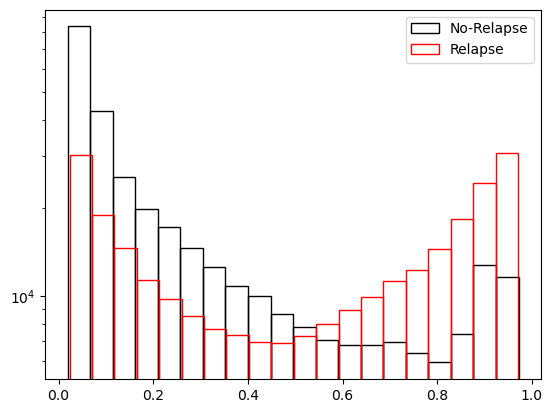

In [7]:
plt.hist(np.array(predictions).flatten()[(np.array(labels).flatten() == 0) & (~patients.isin(trainIds))], bins=20, label='No-Relapse', fill=False, edgecolor='k')
plt.hist(np.array(predictions).flatten()[(np.array(labels).flatten() == 1) & (~patients.isin(trainIds))], bins=20, label='Relapse', fill=False, edgecolor='r')
plt.legend()
plt.yscale('log')
#plt.savefig("histogram_of_embeddings_trainingset.svg")
plt.show()

In [8]:
df_ = adata.obs.copy()
df_

,x,y,cell_types,predictions,patient_id,OR,pdl1_median_pos,pd1_median_pos,HLA-DR_pos,HLA-A_pos,...,CPT1A_pos,CITRATE_SYNTHASE_pos,protein_exp_nb,Hypoxic,OxPhos,Mitochondrial,Oxidative_Stress,Lipid_Oxidation,PPP,Glutamine_import
0,2276.4,1257.7,Tumour,0.787493,TMA_A_A1,0,0.0,0.0,0,0,...,0,1,Oxphos,0,0,0,0,0,1,0
1,2254.4,1261.8,Tumour,0.839252,TMA_A_A1,0,0.0,0.0,0,0,...,0,0,Oxphos,0,0,0,0,0,1,1
2,2234.1,1265.9,Tumour,0.830956,TMA_A_A1,0,0.0,0.0,0,0,...,0,1,low,0,0,0,0,0,1,0
3,2315.7,1273.0,CD4_cells,0.849648,TMA_A_A1,0,0.0,0.0,0,0,...,0,1,low,0,0,0,0,0,1,0
4,2235.7,1276.6,Tumour,0.783558,TMA_A_A1,0,0.0,0.0,0,0,...,0,1,low,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1187506,15794.7,25948.8,Fibroblast,0.956487,TMA_B_J8,1,0.0,0.0,0,0,...,1,0,Glutamineimport_PPP,0,0,0,0,1,1,0
1187507,15808.1,25947.6,Tumour,0.958832,TMA_B_J8,1,0.0,0.0,0,0,...,0,0,Glutamineimport_PPP,0,0,0,0,0,1,0
1187508,15816.2,25947.9,Tumour,0.958134,TMA_B_J8,1,0.0,0.0,0,0,...,0,0,Glutamineimport_PPP,0,0,0,0,0,1,0
1187509,15825.7,25947.6,CD8_cells,0.953808,TMA_B_J8,1,0.0,0.0,0,0,...,1,0,Glutamineimport_PPP,0,0,0,0,1,1,0


In [9]:
df_['pred_cat'] = np.where(df_['predictions'] > 0.5, 'Relapse', 'No-Relapse')

In [22]:
counts = df_.groupby(['patient_id', 'pred_cat', 'cell_types']).size().reset_index(name='count')
counts

/tmp/ipykernel_30825/679481504.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_.groupby(['patient_id', 'pred_cat', 'cell_types']).size().reset_index(name='count')


,patient_id,pred_cat,cell_types,count
0,TMA_A_A1,No-Relapse,B_cells,0
1,TMA_A_A1,No-Relapse,CD4_TFH,0
2,TMA_A_A1,No-Relapse,CD4_cells,0
3,TMA_A_A1,No-Relapse,CD8_cells,0
4,TMA_A_A1,No-Relapse,CD44+,0
...,...,...,...,...
7475,TMA_B_J8,Relapse,Proliferating_MHC_I&II,11
7476,TMA_B_J8,Relapse,Proliferating_MHC_II,2
7477,TMA_B_J8,Relapse,Proliferating_PDL1,1
7478,TMA_B_J8,Relapse,Tumour,4553


In [23]:
totals = counts.groupby(['patient_id', 'pred_cat'])['count'].sum().reset_index(name='total')
totals

/tmp/ipykernel_30825/2854684468.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals = counts.groupby(['patient_id', 'pred_cat'])['count'].sum().reset_index(name='total')


,patient_id,pred_cat,total
0,TMA_A_A1,No-Relapse,2
1,TMA_A_A1,Relapse,4718
2,TMA_A_A2,No-Relapse,1718
3,TMA_A_A2,Relapse,10946
4,TMA_A_A3,No-Relapse,221
...,...,...,...
215,TMA_B_J4,Relapse,2823
216,TMA_B_J7,No-Relapse,17543
217,TMA_B_J7,Relapse,683
218,TMA_B_J8,No-Relapse,34


In [26]:
merged = pd.merge(counts, totals, on=['patient_id', 'pred_cat'])
merged[merged['patient_id'] == 'TMA_A_A1']

,patient_id,pred_cat,cell_types,count,total
0,TMA_A_A1,No-Relapse,B_cells,0,2
1,TMA_A_A1,No-Relapse,CD4_TFH,0,2
2,TMA_A_A1,No-Relapse,CD4_cells,0,2
3,TMA_A_A1,No-Relapse,CD8_cells,0,2
4,TMA_A_A1,No-Relapse,CD44+,0,2
...,...,...,...,...,...
63,TMA_A_A1,Relapse,Proliferating_MHC_I&II,0,4718
64,TMA_A_A1,Relapse,Proliferating_MHC_II,4,4718
65,TMA_A_A1,Relapse,Proliferating_PDL1,0,4718
66,TMA_A_A1,Relapse,Tumour,1085,4718


In [29]:
merged['proportion'] = merged['count'] / merged['total']
merged

,patient_id,pred_cat,cell_types,count,total,proportion
0,TMA_A_A1,No-Relapse,B_cells,0,2,0.000000
1,TMA_A_A1,No-Relapse,CD4_TFH,0,2,0.000000
2,TMA_A_A1,No-Relapse,CD4_cells,0,2,0.000000
3,TMA_A_A1,No-Relapse,CD8_cells,0,2,0.000000
4,TMA_A_A1,No-Relapse,CD44+,0,2,0.000000
...,...,...,...,...,...,...
7475,TMA_B_J8,Relapse,Proliferating_MHC_I&II,11,15206,0.000723
7476,TMA_B_J8,Relapse,Proliferating_MHC_II,2,15206,0.000132
7477,TMA_B_J8,Relapse,Proliferating_PDL1,1,15206,0.000066
7478,TMA_B_J8,Relapse,Tumour,4553,15206,0.299421


In [32]:
agg_stats = merged.groupby(['cell_types', 'pred_cat'])['proportion'].agg(
        mean='mean',
        lower=lambda x: np.nanpercentile(x, 5),
        upper=lambda x: np.nanpercentile(x, 95)
    ).reset_index()
agg_stats

/tmp/ipykernel_30825/330963432.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_stats = merged.groupby(['cell_types', 'pred_cat'])['proportion'].agg(


,cell_types,pred_cat,mean,lower,upper
0,B_cells,No-Relapse,0.020612,0.000000,0.094656
1,B_cells,Relapse,0.031831,0.000000,0.140442
2,CD4_TFH,No-Relapse,0.005738,0.000000,0.026108
3,CD4_TFH,Relapse,0.003098,0.000000,0.014107
4,CD4_cells,No-Relapse,0.096386,0.012126,0.241933
...,...,...,...,...,...
63,Proliferating_PDL1,Relapse,0.001216,0.000000,0.009058
64,Tumour,No-Relapse,0.141828,0.005845,0.432529
65,Tumour,Relapse,0.295998,0.006742,0.668954
66,Vessels,No-Relapse,0.057908,0.007423,0.213710


In [33]:
agg_stats['err_lower'] = agg_stats['mean'] - agg_stats['lower']
agg_stats['err_upper'] = agg_stats['upper'] - agg_stats['mean']

In [34]:
pivot = agg_stats.pivot(index='cell_types', columns='pred_cat', values='mean').reset_index()
pivot

pred_cat,cell_types,No-Relapse,Relapse
0,B_cells,0.020612,0.031831
1,CD4_TFH,0.005738,0.003098
2,CD4_cells,0.096386,0.064962
3,CD8_cells,0.059677,0.037606
4,CD44+,0.048860,0.033361
5,CD44+_PDL1+,0.008649,0.000982
6,Cytotoxic_CD8_cells,0.002716,0.000598
7,Fibroblast,0.106675,0.073580
8,MHC_I,0.024955,0.021419
9,MHC_I&II,0.012027,0.007577


In [36]:
pivot['ratio'] = pivot['No-Relapse']  / pivot['Relapse']
pivot

pred_cat,cell_types,No-Relapse,Relapse,ratio
0,B_cells,0.020612,0.031831,0.647540
1,CD4_TFH,0.005738,0.003098,1.851899
2,CD4_cells,0.096386,0.064962,1.483741
3,CD8_cells,0.059677,0.037606,1.586917
4,CD44+,0.048860,0.033361,1.464592
5,CD44+_PDL1+,0.008649,0.000982,8.805133
6,Cytotoxic_CD8_cells,0.002716,0.000598,4.542258
7,Fibroblast,0.106675,0.073580,1.449784
8,MHC_I,0.024955,0.021419,1.165079
9,MHC_I&II,0.012027,0.007577,1.587380


In [39]:
cell_types = sorted(agg_stats['cell_types'].unique())

In [40]:
agg_stats[agg_stats['pred_cat'] == 'Relapse'].set_index('cell_types').loc[cell_types].reset_index()

,cell_types,pred_cat,mean,lower,upper,err_lower,err_upper
0,B_cells,Relapse,0.031831,0.000000,0.140442,0.031831,0.108611
1,CD44+,Relapse,0.033361,0.000000,0.160480,0.033361,0.127120
2,CD44+_PDL1+,Relapse,0.000982,0.000000,0.003191,0.000982,0.002209
3,CD4_TFH,Relapse,0.003098,0.000000,0.014107,0.003098,0.011009
4,CD4_cells,Relapse,0.064962,0.001304,0.180055,0.063658,0.115093
5,CD8_cells,Relapse,0.037606,0.005689,0.102355,0.031917,0.064749
6,Cytotoxic_CD8_cells,Relapse,0.000598,0.000000,0.003287,0.000598,0.002689
7,Fibroblast,Relapse,0.073580,0.013153,0.173028,0.060426,0.099448
8,MHC_I,Relapse,0.021419,0.000000,0.094085,0.021419,0.072666
9,MHC_I&II,Relapse,0.007577,0.000000,0.040348,0.007577,0.032771


In [10]:
def plot_celltype_proportions(adata, lower_percentile=5, upper_percentile=95, ct_col='cell_types'):
    sns.set(style="whitegrid")

    df = adata.obs.copy()
    df['pred_cat'] = np.where(df['predictions'] > 0.5, 'Relapse', 'No-Relapse')
    
    counts = df.groupby(['patient_id', 'pred_cat', ct_col]).size().reset_index(name='count')
    totals = counts.groupby(['patient_id', 'pred_cat'])['count'].sum().reset_index(name='total')
    merged = pd.merge(counts, totals, on=['patient_id', 'pred_cat'])
    merged['proportion'] = merged['count'] / merged['total']

    agg_stats = merged.groupby([ct_col, 'pred_cat'])['proportion'].agg(
        mean='mean',
        lower=lambda x: np.nanpercentile(x, 5),
        upper=lambda x: np.nanpercentile(x, 95)
    ).reset_index()
    
    agg_stats['err_lower'] = agg_stats['mean'] - agg_stats['lower']
    agg_stats['err_upper'] = agg_stats['upper'] - agg_stats['mean']
    
    pivot = agg_stats.pivot(index=ct_col, columns='pred_cat', values='mean').reset_index()
    pivot['ratio'] = pivot['No-Relapse']  / pivot['Relapse']

    pivot['ratio'] = pivot['ratio'].fillna(4.0)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1], sharex=True)

    cell_types = sorted(agg_stats[ct_col].unique())
    x = np.arange(len(cell_types))
    
    prediction_categories = ['No-Relapse', 'Relapse']
    bar_width = 0.35
    
    for i, cat in enumerate(prediction_categories):
        subset = agg_stats[agg_stats['pred_cat'] == cat].set_index('cell_types').loc[cell_types].reset_index()
        medians = subset['mean']
        errors = [subset['err_lower'], subset['err_upper']]
        xpos = x + (i - 0.5) * bar_width
        axes[0].bar(xpos, medians, width=bar_width, label=cat, alpha=0.7)
        axes[0].errorbar(xpos, medians, yerr=errors, fmt='none', capsize=5, color='black')
    
    axes[0].set_title('Cell Proportions (Num+Den in Regions)in GNN-Predicted Relapse-Associated Regions')
    axes[0].set_ylabel('Proportion')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(cell_types, rotation=0)
    axes[0].legend(title='Predictions')
    axes[0].set_yscale('log')  

    pivot = pivot.set_index(ct_col).loc[cell_types].reset_index()

    axes[1].bar(x, pivot['ratio'], width=0.6, color='skyblue', alpha=0.7)
    axes[1].set_ylabel('Ratio [No-Relapse / Relapse]')
    axes[1].set_xlabel('Cell Type')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(cell_types, rotation=0) s
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].set_ylim([-0.1, 4.0])
    axes[1].hlines(1, x[0], x[-1], lw=2)
    plt.tight_layout()
    plt.savefig("plot_celltype_proportions.svg")
    plt.show()

    return pivot

In [27]:
def plot_marker_proportions_for_marker_cols(
    adata,
    marker_cols,
    lower_percentile=5,
    upper_percentile=95,
    pred_col='predictions'
):

    sns.set(style="whitegrid")
    df = adata.obs.copy()
    df['pred_cat'] = np.where(df[pred_col] > 0.5, 'Relapse', 'No-Relapse')
    
    counts_wide = (
        df
        .groupby(['patient_id', 'pred_cat'])[marker_cols]
        .sum()
        .reset_index()
    )
    counts = (
        counts_wide
        .melt(
            id_vars=['patient_id', 'pred_cat'],
            value_vars=marker_cols,
            var_name='marker',
            value_name='count'
        )
    )

    totals = (
        df
        .groupby(['patient_id', 'pred_cat'])
        .size()
        .reset_index(name='total')
    )

    merged = counts.merge(totals, on=['patient_id', 'pred_cat'])
    merged[['count',	'total']] = merged[['count',	'total']].fillna(0)
    merged['proportion'] = merged['count'] / (merged['total'])# + 1e-5)

    agg = (
        merged
        .groupby(['marker', 'pred_cat'])['proportion']
        .agg(
            mean='mean',
            lower=lambda x: np.nanpercentile(x, lower_percentile),
            upper=lambda x: np.nanpercentile(x, upper_percentile),
        )
        .reset_index()
    )
    agg['err_lower'] = agg['mean'] - agg['lower']
    agg['err_upper'] = agg['upper'] - agg['mean']

    pivot = agg.pivot(index='marker', columns='pred_cat', values='mean').reset_index()
    pivot['ratio'] = pivot['No-Relapse'] / pivot['Relapse']
    pivot = pivot.fillna(4.0)

    # ----------- plotting -----------
    markers = sorted(agg['marker'].unique())
    x = np.arange(len(markers))
    cats = ['No-Relapse', 'Relapse']
    w = 0.35

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), 
                                   gridspec_kw={'height_ratios':[3,1]}, sharex=True)

    for i, cat in enumerate(cats):
        sub = agg[agg['pred_cat']==cat].set_index('marker').loc[markers]
        xpos = x + (i-0.5)*w
        ax1.bar(xpos, sub['mean'], width=w, label=cat, alpha=0.7)
        ax1.errorbar(xpos, sub['mean'], 
                     yerr=[sub['err_lower'], sub['err_upper']],
                     fmt='none', capsize=5, color='black')

    ax1.set_title('Marker Proportions by Prediction Category (Num+Den in Regions)')
    ax1.set_ylabel('Proportion')
    ax1.set_yscale('log')
    ax1.legend(title='Prediction')
    ax1.set_xticks(x)
    ax1.set_xticklabels(markers, rotation=0)

    ordered = pivot.set_index('marker').loc[markers].reset_index()
    ax2.bar(x, ordered['ratio'], width=0.6, alpha=0.7)
    ax2.set_ylabel('Ratio (No-Relapse / Relapse)')
    ax2.hlines(1, x[0], x[-1], colors='gray', linestyles='dashed')
    ax2.set_xticks(x)
    ax2.set_xticklabels(markers, rotation=90)
    ax2.set_xlabel('Marker')
    ax2.set_ylim([-0.1, 4])
    plt.tight_layout()
    plt.savefig("plot_marker_proportions_for_marker_cols_tumoronly.svg")
    plt.show()

    return

/tmp/ipykernel_241766/3878029531.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['patient_id', 'pred_cat'])[marker_cols]
/tmp/ipykernel_241766/3878029531.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['patient_id', 'pred_cat'])


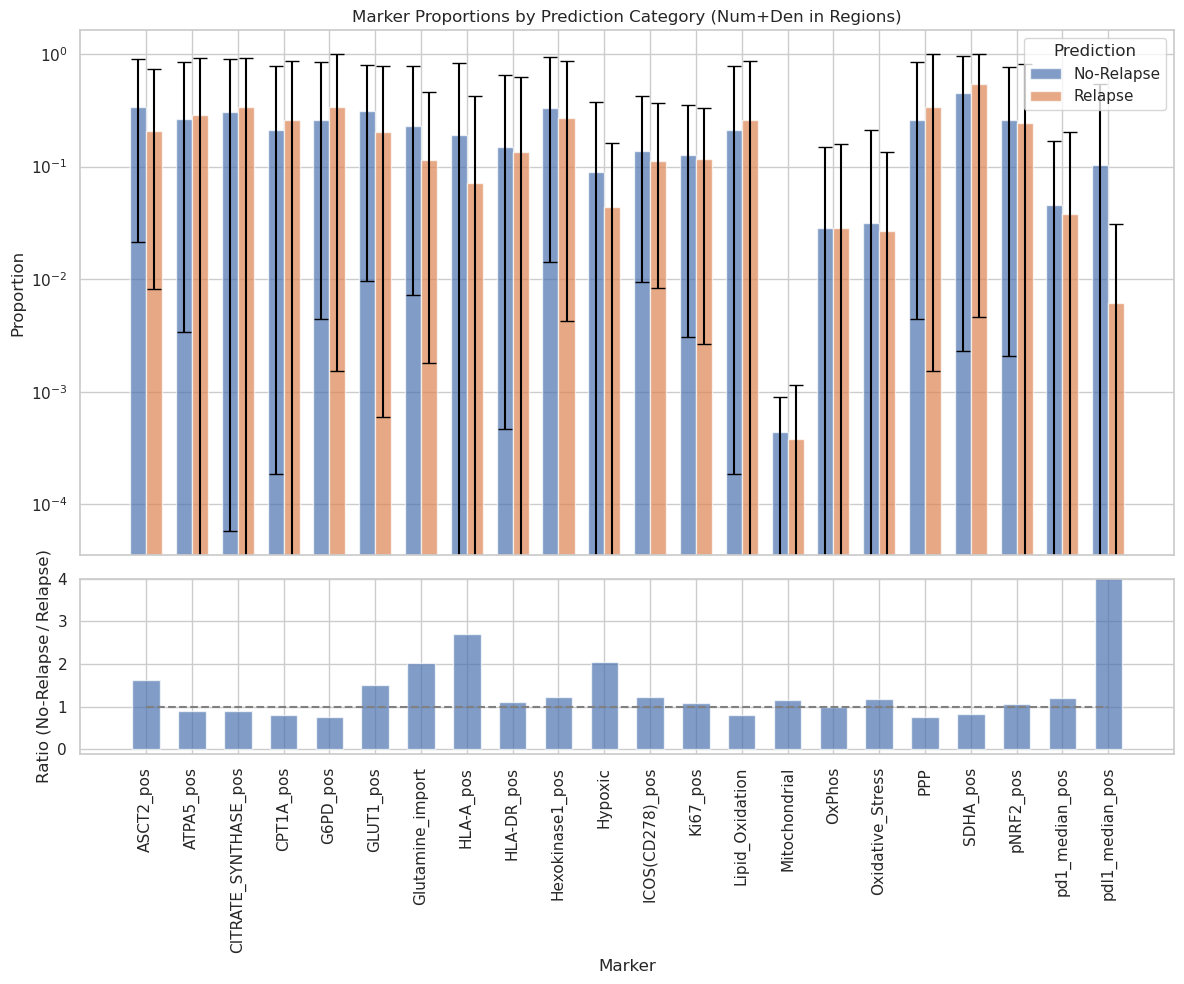

In [20]:
plot_marker_proportions_for_marker_cols(adata[~adata.obs['cell_types'].isin(['Other_Stromal_cells', 'Macrophages', 'Fibroblast', 'CD4_cells', 'CD8_cells', 'Vessels', 'Macrophages_M2', 'B_cells', 'Macrophages_PDL1+', 'Macrophages_M2_PDL1+', 'CD4_TFH', 'Cytotoxic_CD8_cells'])], marker_cols=markers_for_stats)

/tmp/ipykernel_241766/385785804.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['patient_id', 'pred_cat'])[marker_cols]
/tmp/ipykernel_241766/385785804.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['patient_id', 'pred_cat'])


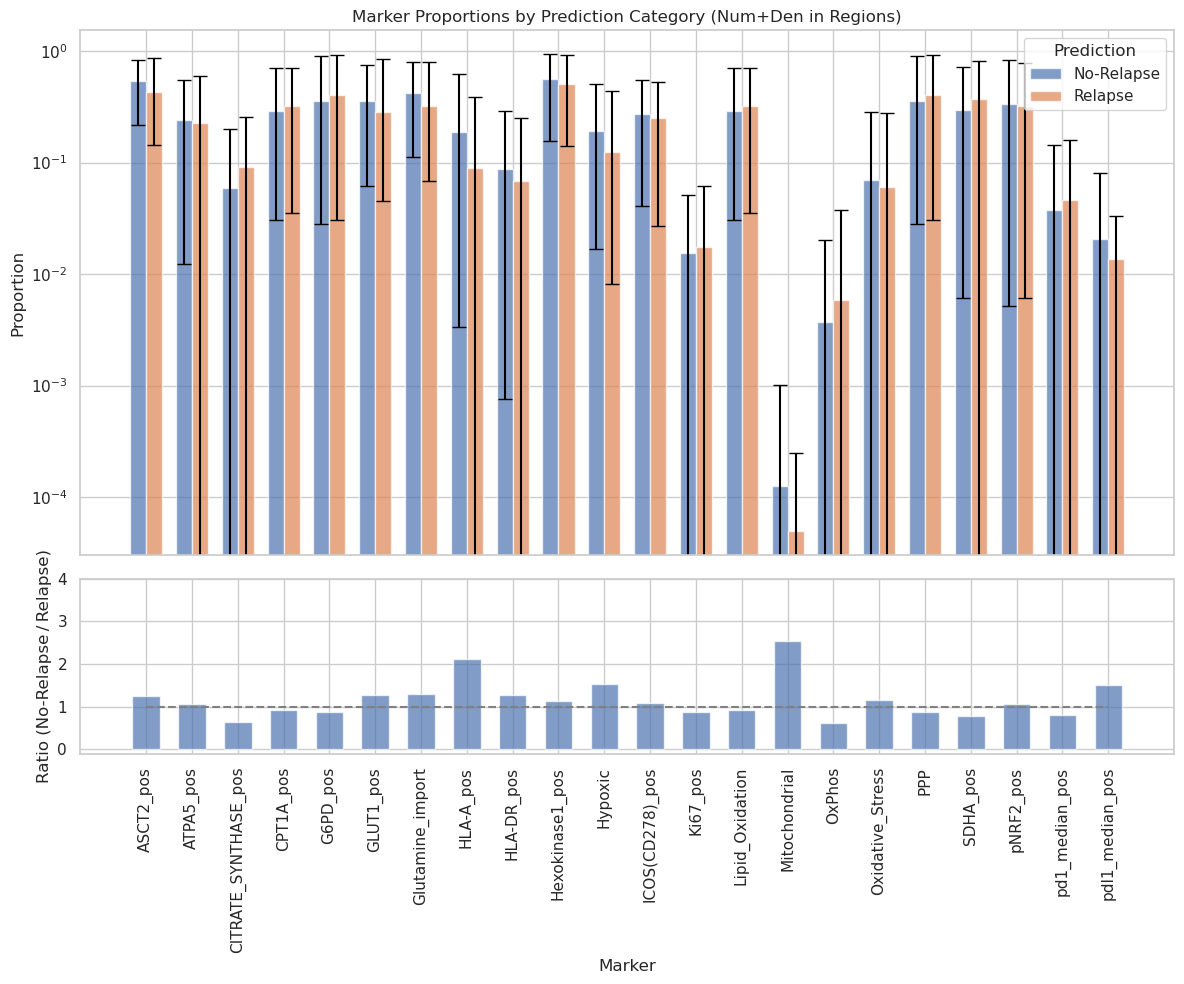

In [26]:
plot_marker_proportions_for_marker_cols(adata[adata.obs['cell_types'].isin(['Other_Stromal_cells', 'Fibroblast', 'Vessels'])], marker_cols=markers_for_stats)#'Other_Stromal_cells', 'Fibroblast', 'Vessels', 

/tmp/ipykernel_30825/1674128133.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['patient_id', 'pred_cat', ct_col]).size().reset_index(name='count')
/tmp/ipykernel_30825/1674128133.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals = counts.groupby(['patient_id', 'pred_cat'])['count'].sum().reset_index(name='total')
/tmp/ipykernel_30825/1674128133.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence thi

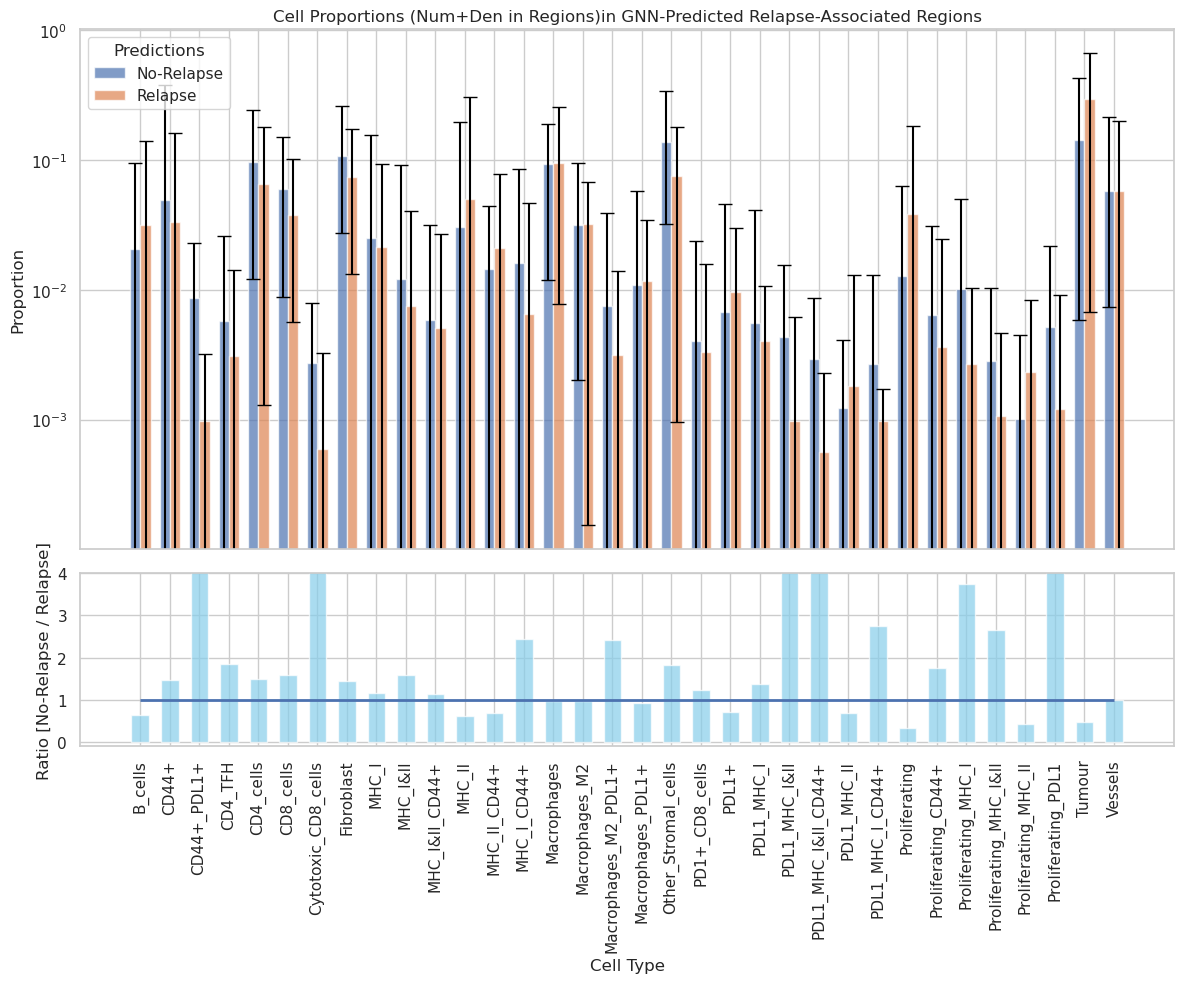

In [75]:
props_ = plot_celltype_proportions(adata, ct_col='cell_types')

In [94]:
#  Now compute whole-core proportions

In [78]:
def plot_celltype_wholecore_proportions(adata, lower_percentile=5, upper_percentile=95, ct_col='cell_types'):
    sns.set(style="whitegrid")

    df = adata.obs.copy()
    df['pred_cat'] = np.where(df['predictions'] > 0.5, 'Relapse', 'No-Relapse')
    
    counts = df.groupby(['patient_id', 'pred_cat', ct_col]).size().reset_index(name='count')
    totals = counts.groupby(['patient_id'])['count'].sum().reset_index(name='total')
    merged = pd.merge(counts, totals, on=['patient_id'])
    merged['proportion'] = merged['count'] / (merged['total'])# + 1e-5)

    agg_stats = merged.groupby([ct_col, 'pred_cat'])['proportion'].agg(
        mean='mean',
        lower=lambda x: np.nanpercentile(x, 5),
        upper=lambda x: np.nanpercentile(x, 95)
    ).reset_index()

    agg_stats['err_lower'] = agg_stats['mean'] - agg_stats['lower']
    agg_stats['err_upper'] = agg_stats['upper'] - agg_stats['mean']
    
    pivot = agg_stats.pivot(index=ct_col, columns='pred_cat', values='mean').reset_index()
    pivot['ratio'] = pivot['No-Relapse']  / pivot['Relapse']

    pivot['ratio'] = pivot['ratio'].fillna(4.0)
    pivot['ratio'] = pivot['ratio'].replace({np.inf: 4.0})
    

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[3, 1], sharex=True)
    cell_types = sorted(agg_stats[ct_col].unique())
    x = np.arange(len(cell_types))
    
    prediction_categories = ['No-Relapse', 'Relapse']
    bar_width = 0.35
    
    myRatios = []
    for i, cat in enumerate(prediction_categories):
        subset = agg_stats[agg_stats['pred_cat'] == cat].set_index(ct_col).loc[cell_types].reset_index()
        medians = subset['mean']
        errors = [subset['err_lower'], subset['err_upper']]
        xpos = x + (i - 0.5) * bar_width
        axes[0].bar(xpos, medians, width=bar_width, label=cat, alpha=0.7)
        axes[0].errorbar(xpos, medians, yerr=errors, fmt='none', capsize=5, color='black')
        myRatios.append(medians)
    myRatios = myRatios[1]/myRatios[0]
    
    axes[0].set_title('Cell Proportions of Whole Core (positive counts within GNN-Predicted Relapse-Associated Regions)')
    axes[0].set_ylabel('Proportion')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(cell_types, rotation=0)
    axes[0].legend(title='Predictions')
    axes[0].set_yscale('log')  # Set the y-axis to a logarithmic scale

    pivot = pivot.set_index(ct_col).loc[cell_types].reset_index()
    
    axes[1].bar(x, pivot['ratio'], width=0.6, color='skyblue', alpha=0.7)
    axes[1].set_ylabel('Ratio [No-Relapse / Relapse]')
    axes[1].set_xlabel('Cell Type')
    axes[1].hlines(1, x[0], x[-1], 'r', ls='--', lw=2)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(cell_types, rotation=0)  # Do not rotate the x-axis labels
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].set_ylim([0.5, 4.0])

    plt.tight_layout()
    plt.savefig("plot_celltype_wholecore_proportions.svg")
    plt.show()

    return

/tmp/ipykernel_30825/1361542205.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['patient_id', 'pred_cat', ct_col]).size().reset_index(name='count')
/tmp/ipykernel_30825/1361542205.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  totals = counts.groupby(['patient_id'])['count'].sum().reset_index(name='total')
/tmp/ipykernel_30825/1361542205.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
 

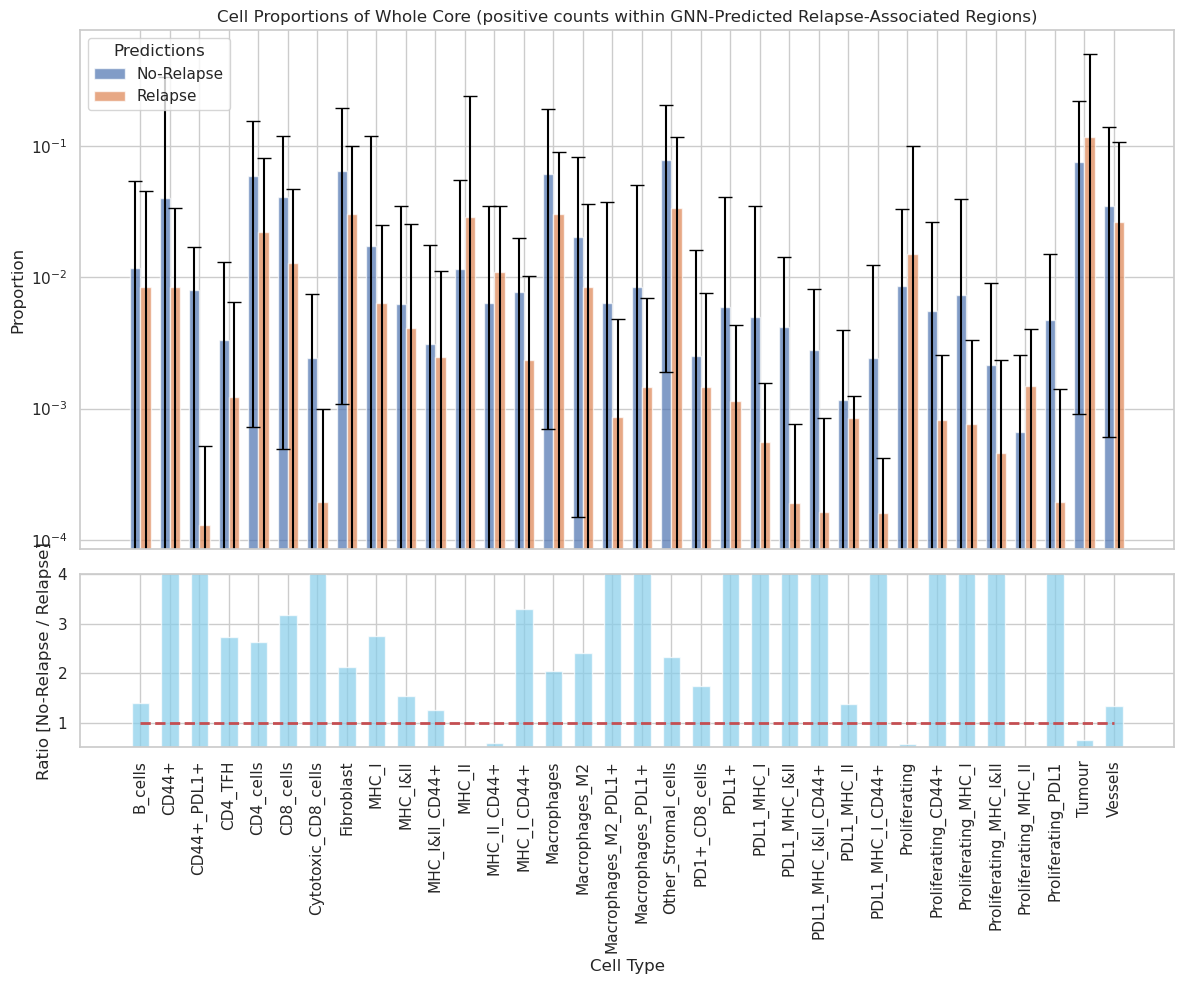

In [79]:
plot_celltype_wholecore_proportions(adata, ct_col='cell_types')

In [80]:
cell_types = sorted(adata.obs['cell_types'].unique())
n_nodes = adata.n_obs
n_cell_types = len(cell_types)

prop_matrix = np.zeros((n_nodes, n_cell_types))

for pid, idx in adata.obs.groupby('patient_id').groups.items():
    indices = list(idx)
    padata = adata[indices, :].copy().obs.reset_index(drop=True)
    coords = padata.loc[:, ['x', 'y']].values

    nbrs = NearestNeighbors(n_neighbors=31, algorithm='auto').fit(coords)
    distances, neighbors = nbrs.radius_neighbors(coords, radius=160.0)
    
    neighbors = [neighbors[i] for i in range(len(neighbors))]

    ct_series = padata['cell_types']
    
    for pos, node_idx in enumerate(indices):
        neighbor_positions = neighbors[pos]
        neighbor_ct = ct_series.iloc[neighbor_positions]
        counts = neighbor_ct.value_counts(normalize=True).reindex(index = cell_types)
        for col_idx, ct in enumerate(cell_types):
            prop_matrix[int(node_idx), col_idx] = counts.get(ct, 0)

adata.obsm['cell_type_proportions'] = prop_matrix

/tmp/ipykernel_30825/1139174547.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pid, idx in adata.obs.groupby('patient_id').groups.items():


In [81]:
df_props = pd.DataFrame(prop_matrix, index=adata.obs.index, columns=cell_types)

df_props['patient_id'] = adata.obs['patient_id']
df_props['predictions'] = adata.obs['predictions']

df_props['prediction_group'] = np.where(df_props['predictions'] > 0.5, 'Relapse', 'No-Relapse')

df_long = df_props.melt(id_vars=['patient_id', 'predictions', 'prediction_group'],
                        value_vars=cell_types,
                        var_name='cell_types',
                        value_name='proportion')


patient_summary = df_long.groupby(['patient_id', 'prediction_group', 'cell_types'])['proportion'] \
                          .mean().reset_index()
patient_summary.rename(columns={'proportion': 'patient_median'}, inplace=True)


agg_summary = patient_summary.groupby(['prediction_group', 'cell_types']).agg(
    overall_median=('patient_median', 'mean'),
    overall_q25=('patient_median', lambda x: np.nanpercentile(x, 5)),
    overall_q75=('patient_median', lambda x: np.nanpercentile(x, 95))
).reset_index()


cell_types_order = sorted(agg_summary['cell_types'].unique())
x = np.arange(len(cell_types_order))
width = 0.35  # The width for each bar in a group.

groups = sorted(agg_summary['prediction_group'].unique())

/tmp/ipykernel_30825/2399156390.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_summary = df_long.groupby(['patient_id', 'prediction_group', 'cell_types'])['proportion'] \


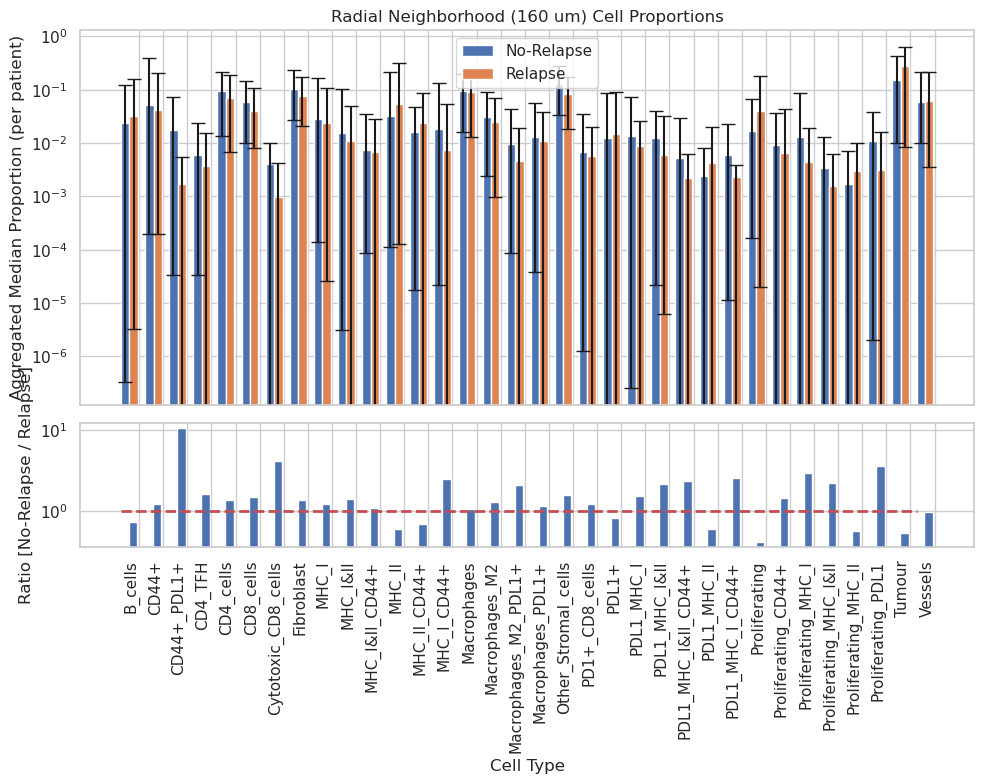

In [83]:
patient_ratio = patient_summary.pivot(index=['patient_id', 'cell_types'],
                                      columns='prediction_group',
                                      values='patient_median').reset_index()


patient_ratio['ratio'] = patient_ratio['No-Relapse'] / patient_ratio['Relapse']
patient_ratio['ratio'] = patient_ratio['ratio'].fillna(4.0)
patient_ratio['ratio'] = patient_ratio['ratio'].replace({np.inf: 4.0})

cell_types_order = sorted(agg_summary['cell_types'].unique())

x = np.arange(len(cell_types_order))
width = 0.35  # width for the proportions plot

groups = sorted(agg_summary['prediction_group'].unique())

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 8), height_ratios=[3, 1], sharex=True)

myRatios = []
for i, group in enumerate(groups):
    df_grp = agg_summary[agg_summary['prediction_group'] == group].set_index('cell_types').reindex(cell_types_order)
    medians = df_grp['overall_median'].values
    lower_errors = np.abs(medians - df_grp['overall_q25'].values)
    upper_errors = np.abs(df_grp['overall_q75'].values - medians)
    errors = [lower_errors, upper_errors]
    ax1.bar(x + (i + 0.5) * width, medians, width=width, yerr=errors, capsize=5, label=group)
    myRatios.append(medians)
myRatios = myRatios[0]/myRatios[1]

ax1.set_ylabel("Aggregated Median Proportion (per patient)")
ax1.set_title("Radial Neighborhood (160 um) Cell Proportions")
ax1.legend()
ax1.set_yscale('log')


ax2.bar(x+0.5, myRatios, width=width, capsize=5)
ax2.set_ylabel("Ratio [No-Relapse / Relapse]")
ax2.set_xlabel("Cell Type")

ax2.set_xticks(x+0.75)
ax2.set_xticklabels(cell_types_order, rotation=90, ha='right')
ax2.hlines(1, x[0], x[-1], 'r', ls='--', lw=2)
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig("radialNeighborhoodproportions.svg")
plt.show()

# Plot in the data

In [132]:
cell_types_colors = {
        "Tumour": "#d6336f",
        "Other_Stromal_cells": "#4aa0ea", # a lighter blue; related to b cells
        "Macrophages": "#9023f6", # Brighter purple
        "Fibroblast": "#622d04", # brown, reminiscent of VIM staining with HRP DAB
        "CD4_cells": "#49ad37", # base green
        "Vessels": "#d86e53", # a redder brown / orange
        "CD8_cells": "#4a118a", # Darker purple to represent more density and size
        "CD44+": "#d6336faa",
        "MHC_II": "#d6336faa",
        "Macrophages_M2": "#cfcec1", # Muted version of the other cells
        "B_cells": "#4a65ea", # Dark blue
        "Proliferating": "#d6336fdd",
        "MHC_II_CD44+": "#d6336faa",
        "MHC_I": "#d6336faa",
        "MHC_I&II": "#d6336faa",
        "MHC_I_CD44+": "#d6336faa",
        "Proliferating_MHC_I": "#d6336fdd",
        "Macrophages_M2_PDL1+": "#87b09a", # muted green
        "Macrophages_PDL1+": "#b292d8", # Muted version of hte myeloid_cells
        "MHC_I&II_CD44+": "#d6336faa",
        "PDL1_MHC_I&II": "#d6336fff",
        "CD44+_PDL1+": "#d6336fff",
        "Proliferating_CD44+": "#d6336fff",
        "CD4_TFH": "#86807a", # Muted version of the other cells
        "PDL1+": "#d6336fff",
        "PD1+_CD8_cells": "#da6fd2", # pink, related to blood. avoid red to not confused with 'detrimental' cells like tumor cells
        "Cytotoxic_CD8_cells": "#22d595", # a more toxic, brighter turq,green to indicate killing function
        "PDL1_MHC_I": "#d6336fff",
        "Proliferating_PDL1": "#d6336fff",
        "PDL1_MHC_II": "#d6336fff",
        "Proliferating_MHC_II": "#d6336fff",
        "PDL1_MHC_I&II_CD44+": "#d6336fff",
        "Proliferating_MHC_I&II": "#d6336fff",
        "PDL1_MHC_I_CD44+": "#d6336fff",
    }

TMA_B_H4


/tmp/ipykernel_3268/1358922398.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T


Remember, A score of 1 is Relapse
Actual Relapse:  No Relapse
Predicted Relapse:  0.11290401


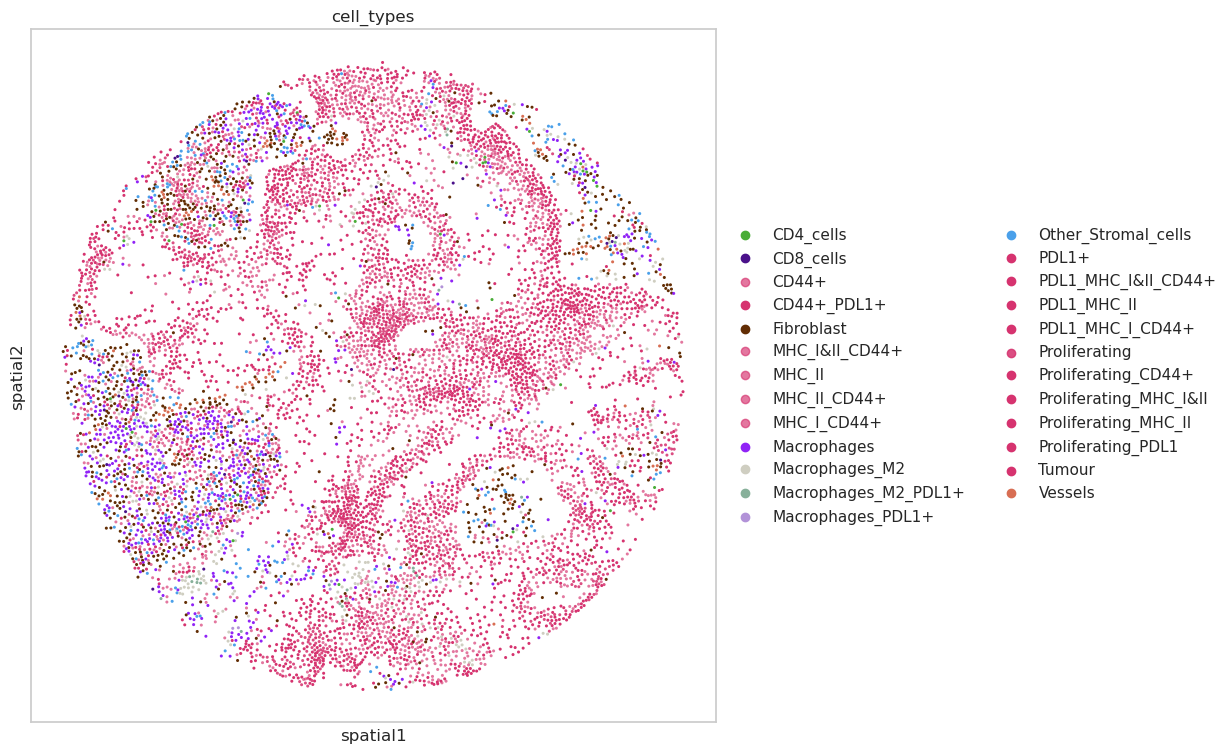

TMA_B_D8


/tmp/ipykernel_3268/1358922398.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T


Remember, A score of 1 is Relapse
Actual Relapse:  No Relapse
Predicted Relapse:  0.057224657


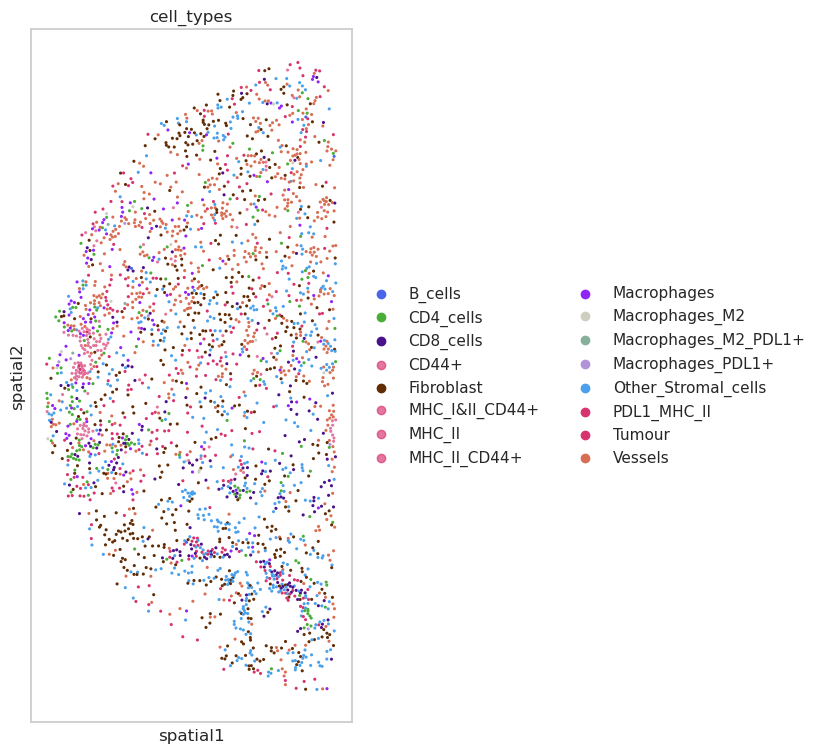

TMA_A_C7


/tmp/ipykernel_3268/1358922398.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T


Remember, A score of 1 is Relapse
Actual Relapse:  Relapse
Predicted Relapse:  0.4251614


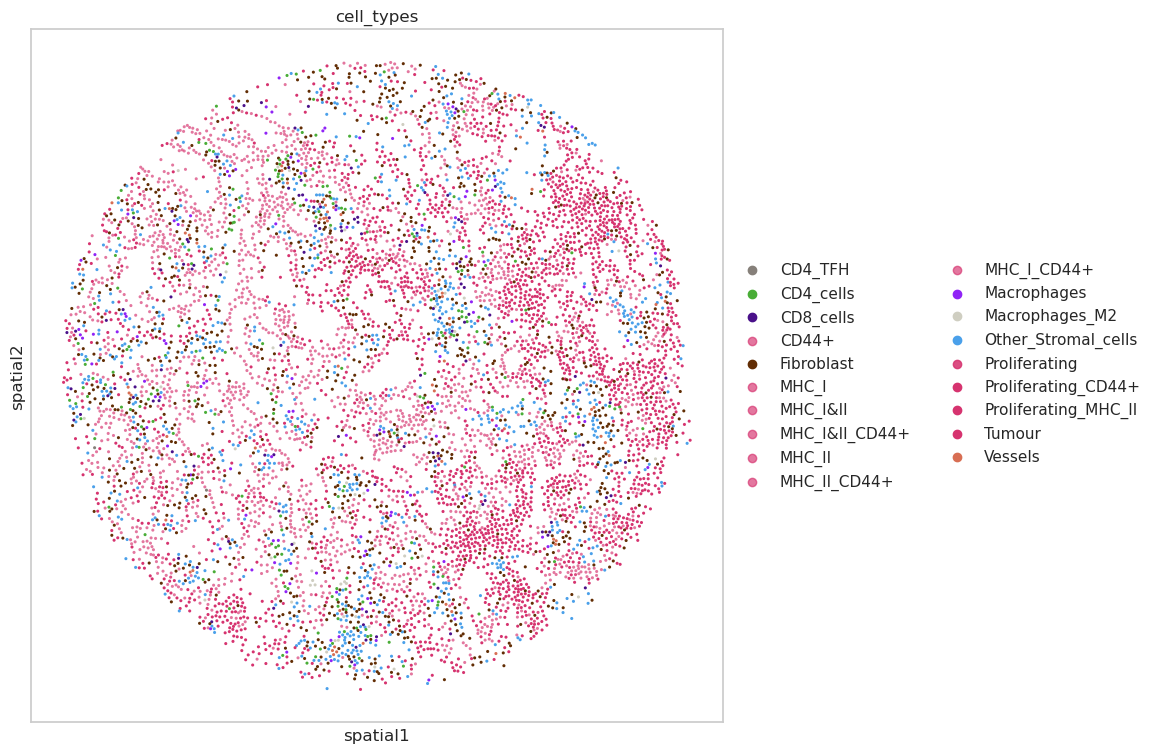

TMA_A_B6


/tmp/ipykernel_3268/1358922398.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T


Remember, A score of 1 is Relapse
Actual Relapse:  Relapse
Predicted Relapse:  0.61626405


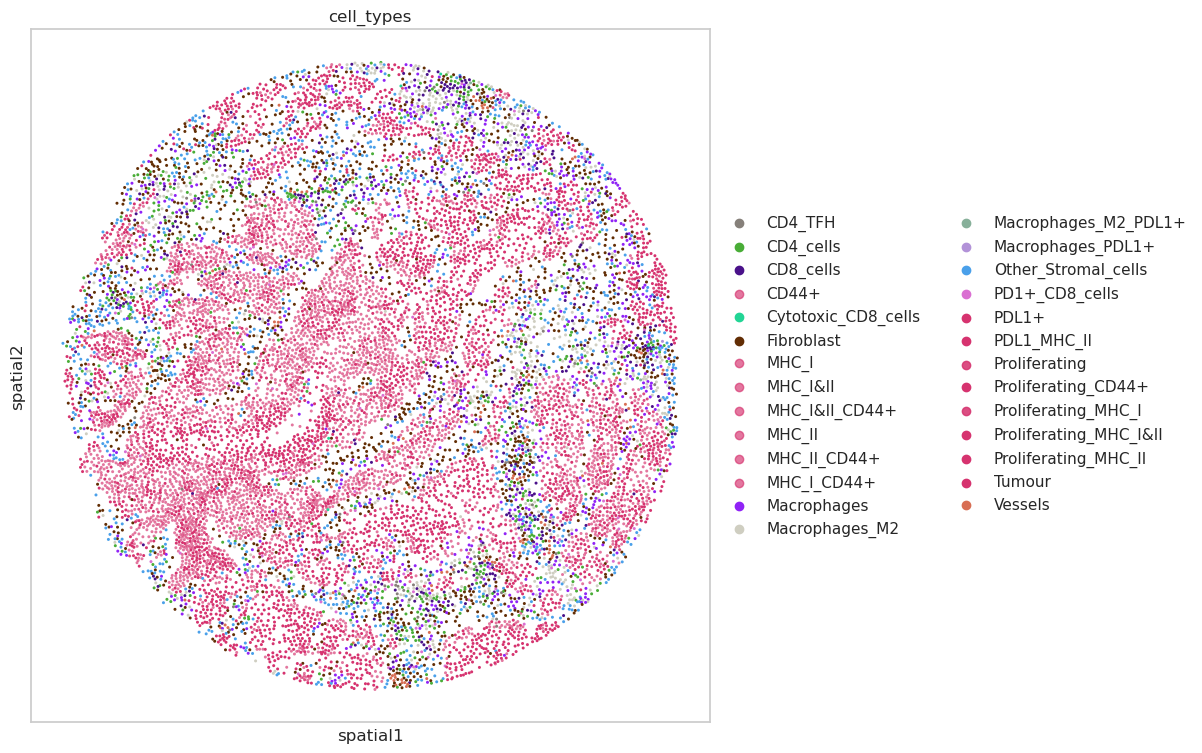

TMA_A_F3


/tmp/ipykernel_3268/1358922398.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T


Remember, A score of 1 is Relapse
Actual Relapse:  No Relapse
Predicted Relapse:  0.6376529


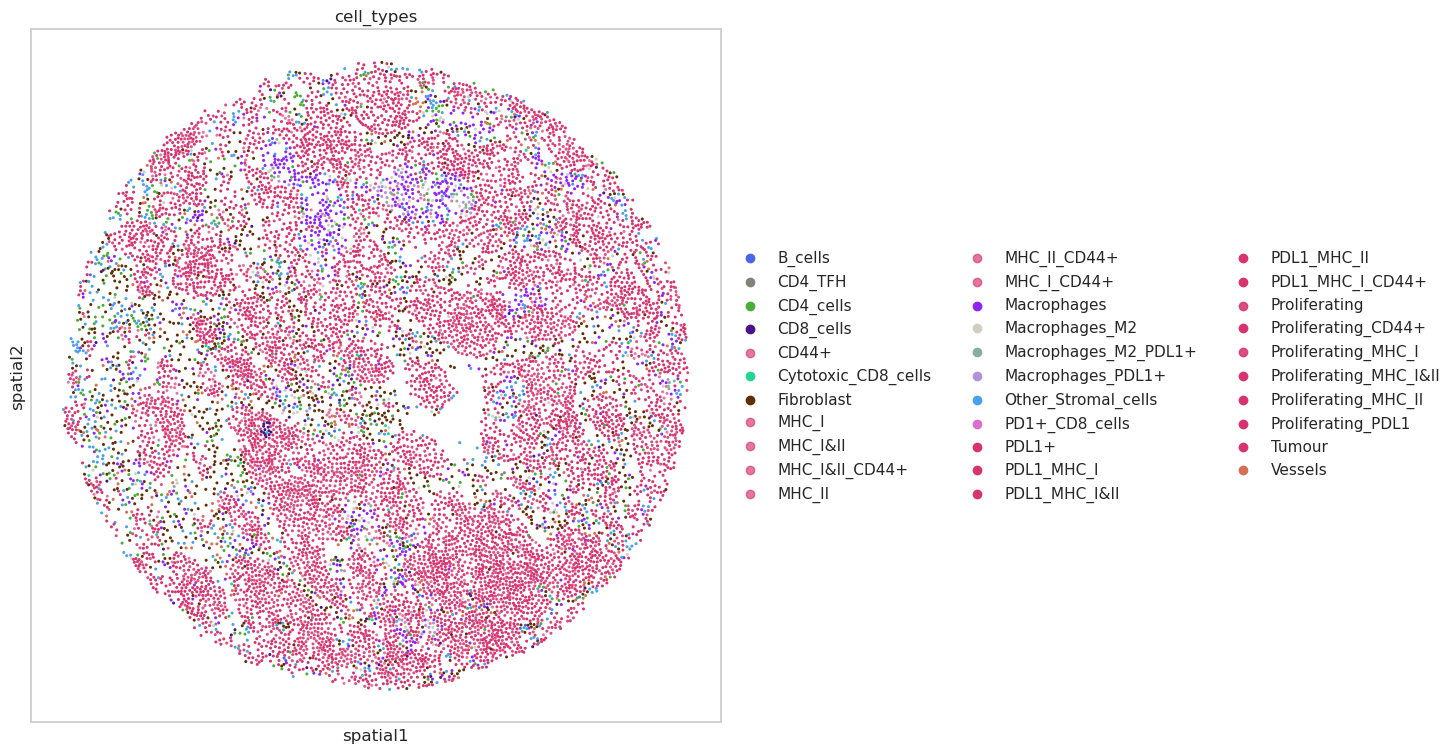

TMA_A_B4


/tmp/ipykernel_3268/1358922398.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T


Remember, A score of 1 is Relapse
Actual Relapse:  No Relapse
Predicted Relapse:  0.21997294


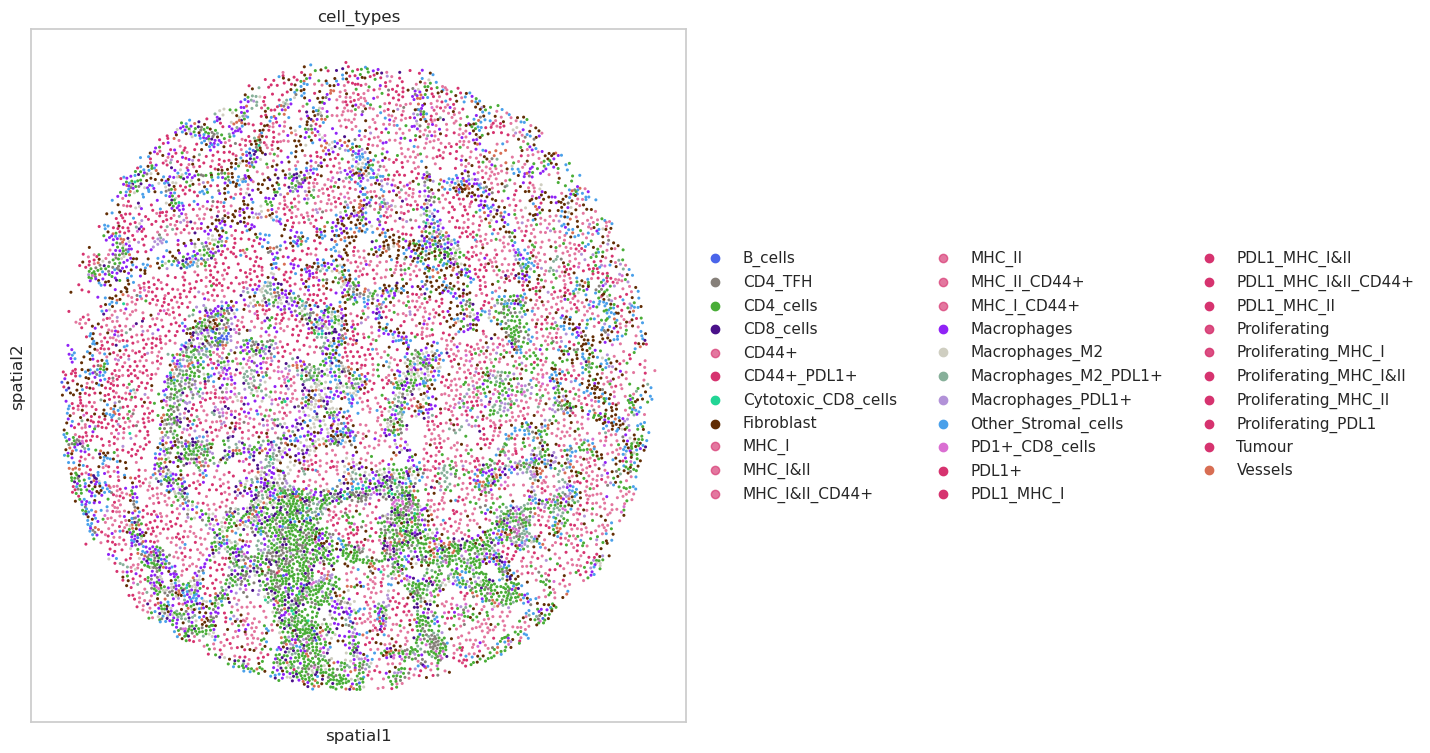

TMA_B_C8


/tmp/ipykernel_3268/1358922398.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T


Remember, A score of 1 is Relapse
Actual Relapse:  No Relapse
Predicted Relapse:  0.11695957


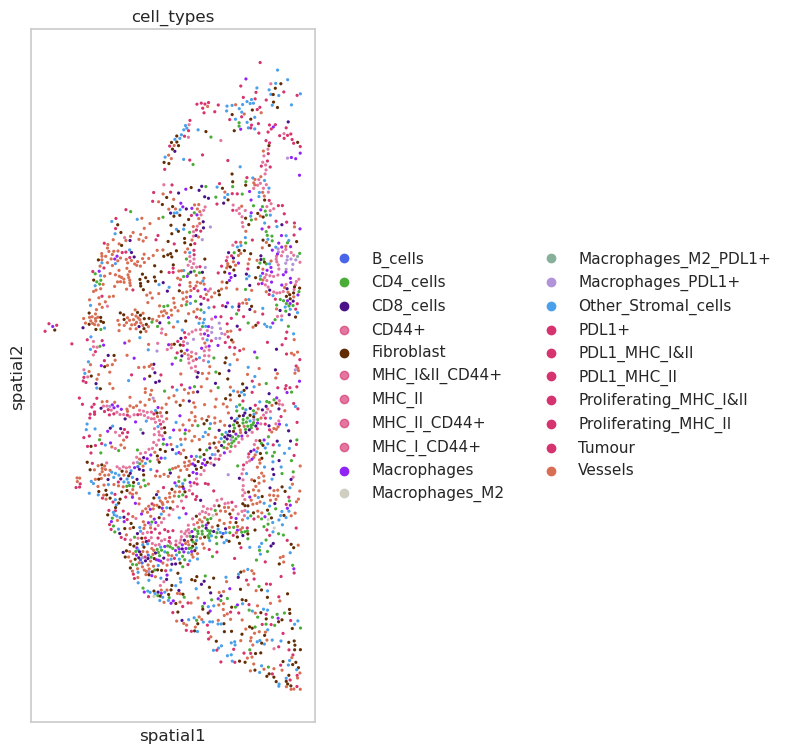

TMA_A_A7


/tmp/ipykernel_3268/1358922398.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T


Remember, A score of 1 is Relapse
Actual Relapse:  Relapse
Predicted Relapse:  0.53640515


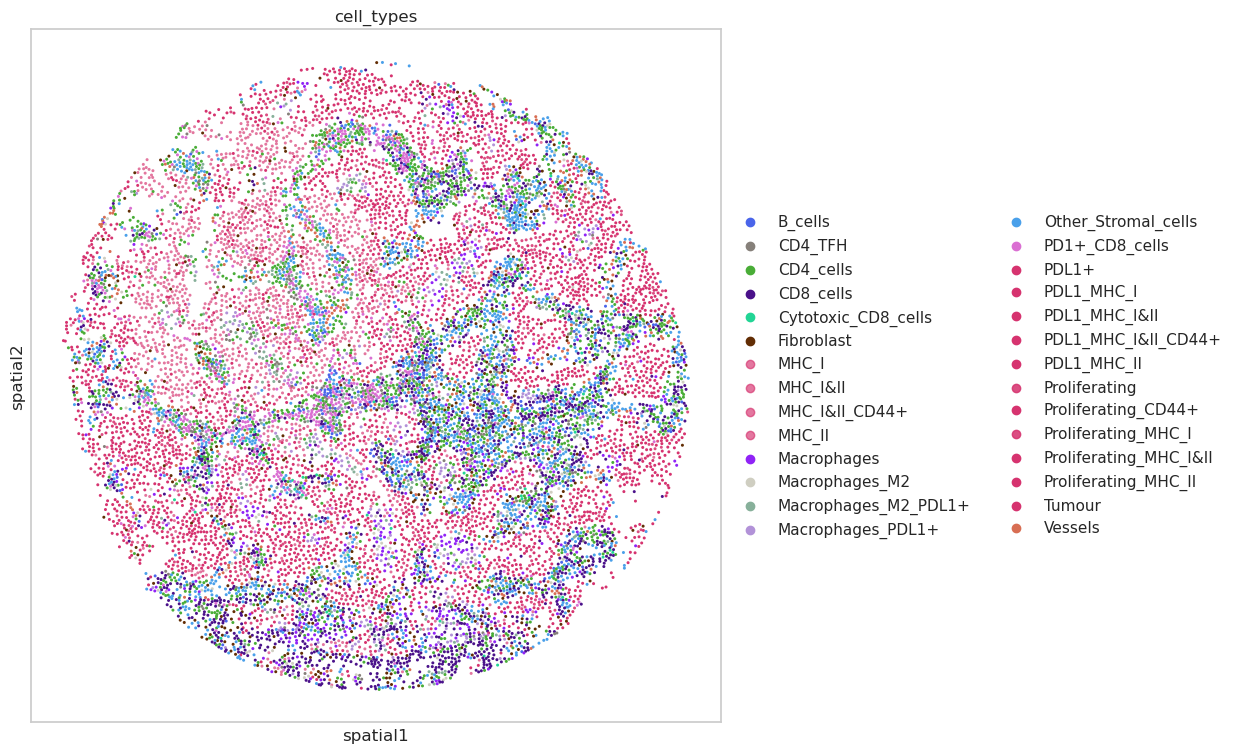

TMA_B_C5


/tmp/ipykernel_3268/1358922398.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T


Remember, A score of 1 is Relapse
Actual Relapse:  No Relapse
Predicted Relapse:  0.23768122


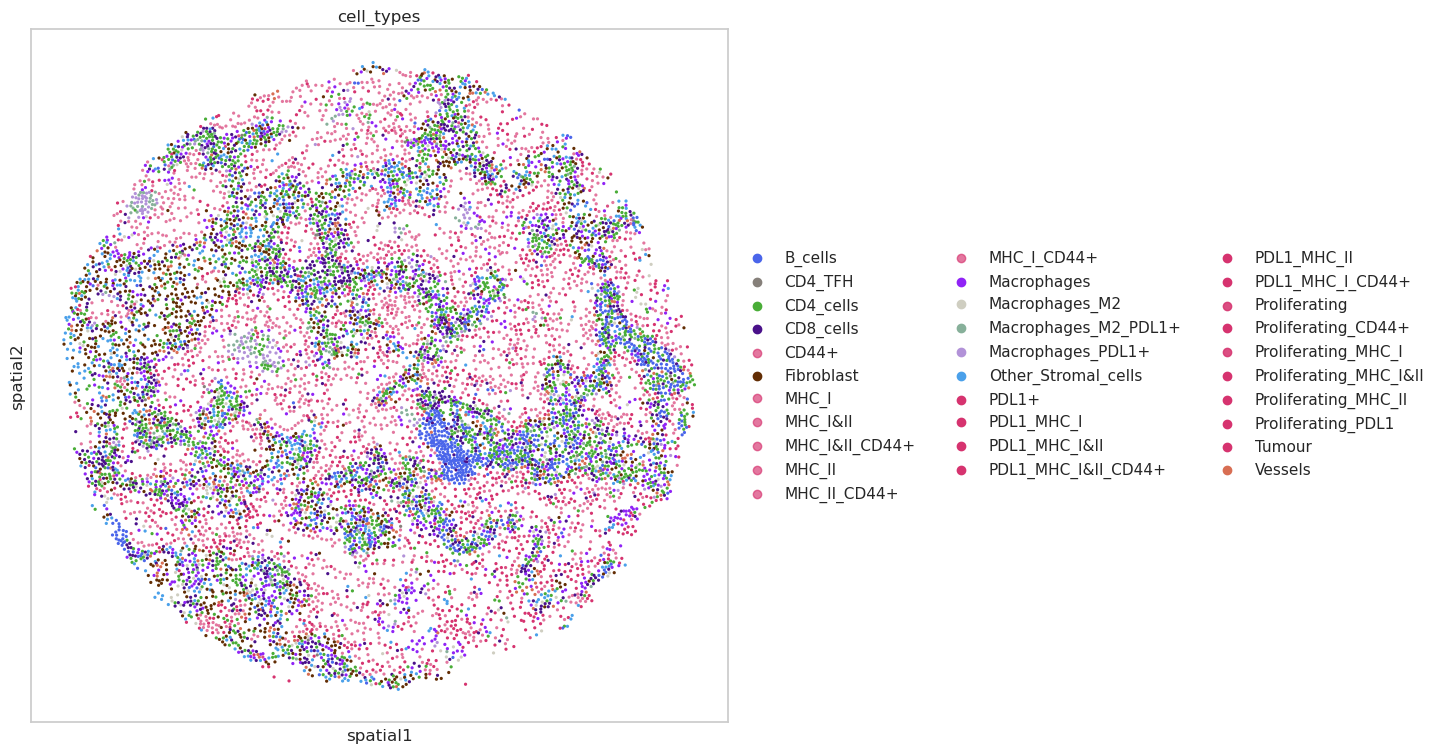

TMA_A_E7


/tmp/ipykernel_3268/1358922398.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T


Remember, A score of 1 is Relapse
Actual Relapse:  Relapse
Predicted Relapse:  0.8139176


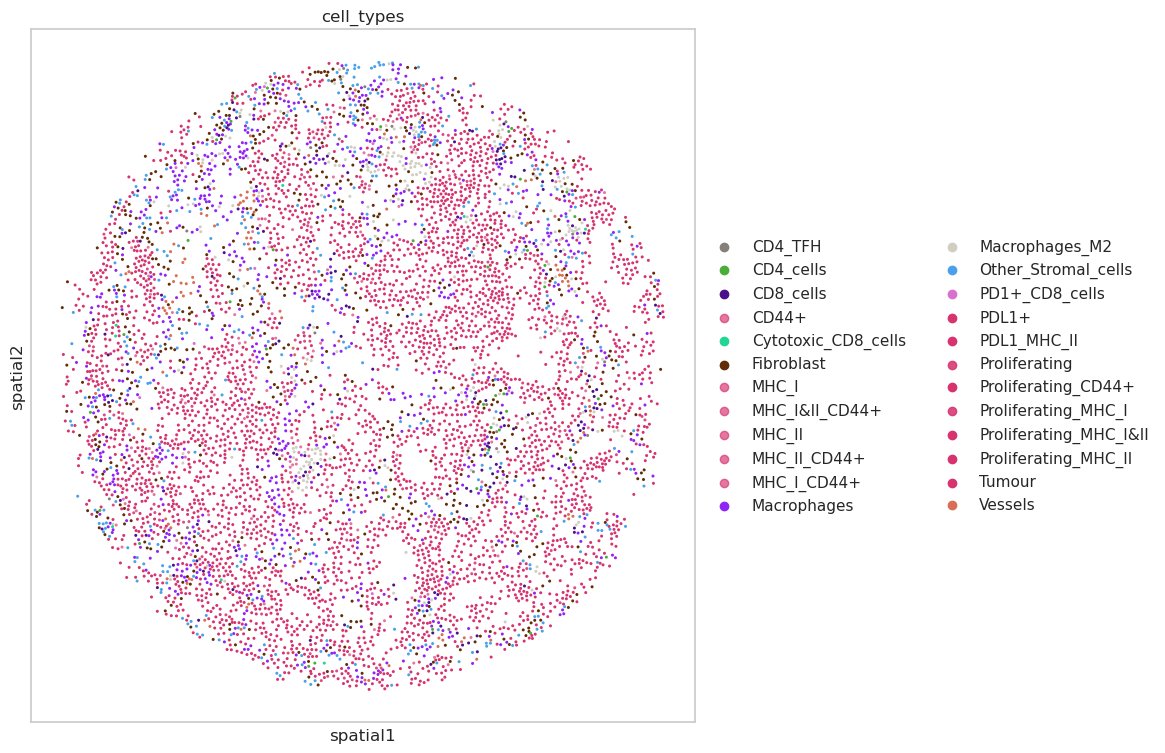

TMA_A_A6


/tmp/ipykernel_3268/1358922398.py:7: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T


Remember, A score of 1 is Relapse
Actual Relapse:  Relapse
Predicted Relapse:  0.8280254



KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x7cfb7c466c20> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

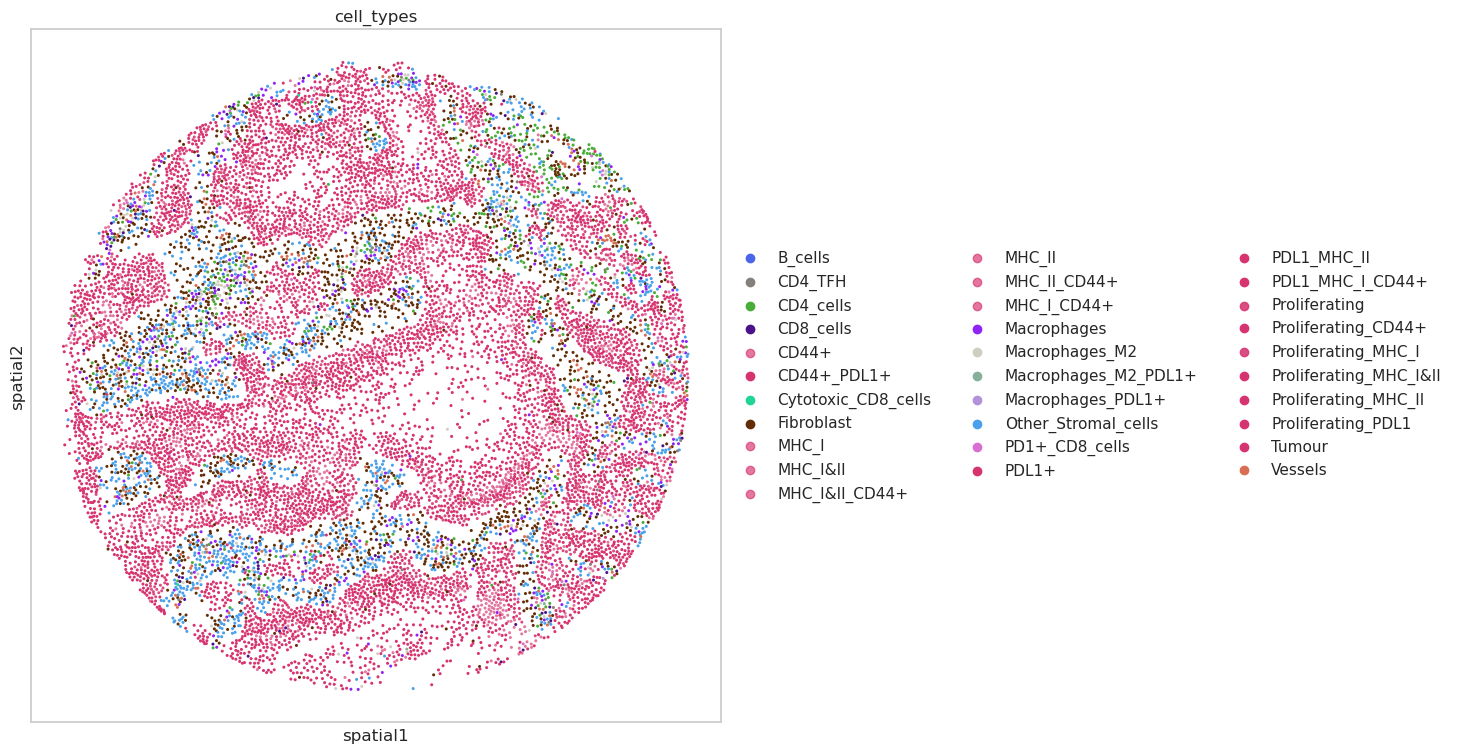

In [ ]:
actual_relapse, pred_relapse = [], []
for pat in range(len(list(set(adata.obs['patient_id'])))):

    print(list(set(adata.obs['patient_id']))[pat])
    normadata = adata.copy()
    normadata = normadata[normadata.obs['patient_id'] == list(set(normadata.obs['patient_id']))[pat]]
    normadata.obsm['spatial'] = np.vstack([normadata.obs.x, normadata.obs.y]).T

    print("Remember, A score of 1 is Relapse")
    print("Actual Relapse: ", "No Relapse" if adata[adata.obs['patient_id'] == list(set(adata.obs['patient_id']))[pat]].obs.OR.iloc[0] == 0 else "Relapse")
    print("Predicted Relapse: ", normadata.obs['predictions'].mean())

    actual_relapse.append(adata[adata.obs['patient_id'] == list(set(adata.obs['patient_id']))[pat]].obs.OR.iloc[0])
    pred_relapse.append(normadata.obs['predictions'].mean())

    fig, ax = plt.subplots(ncols=1, figsize=(9, 9))
    ax.set_aspect('equal', 'box')
    ax.set_rasterization_zorder(0)
    sc.pl.spatial(normadata, color='cell_types', ax=ax, show=False, palette=cell_types_colors, spot_size=8)
    plt.savefig(f'Figure7c_{pat}_ct.tiff', dpi=400)
    plt.show()


In [49]:
normadata = adata.copy()

In [139]:
normadata

View of AnnData object with n_obs × n_vars = 4720 × 0
    obs: 'x', 'y', 'cell_types', 'predictions', 'patient_id', 'OR', 'pdl1_median_pos', 'pd1_median_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'Ki67_pos', 'G6PD_pos', 'pNRF2_pos', 'ATPA5_pos', 'GLUT1_pos', 'Hexokinase1_pos', 'ASCT2_pos', 'SDHA_pos', 'CPT1A_pos', 'CITRATE_SYNTHASE_pos', 'protein_exp_nb', 'Hypoxic', 'OxPhos', 'Mitochondrial', 'Oxidative_Stress', 'Lipid_Oxidation', 'PPP', 'Glutamine_import'
    obsm: 'cell_type_proportions'

In [180]:
actual_relapse, pred_relapse = [], []

for pat in adataClinical.obs['unique_core'].unique():

    if pat not in adata.obs['patient_id'].unique():
        continue

    print(pat)
    normadata = adata.copy()
    normadata.obsm['spatial'] = np.vstack([normadata.obs['x'], normadata.obs['y']]).T
    
    normadata = normadata[normadata.obs['patient_id'].astype(str) == pat]

    bol = normadata.obs['nb_tumour_nontumour_50_2'] == 'Tumour'

    print("Remember, A score of 1 is Relapse")
    print("Actual Relapse: ", "No Relapse" if normadata[normadata.obs['patient_id'] == pat,:].obs.OR.iloc[0] == 0 else "Relapse")
    print("Predicted Relapse: ", normadata.obs['predictions'].mean())
    print("Predicted Relapse TumourCells: ", normadata.obs.loc[bol.values, 'predictions'].mean())
    print("Predicted Relapse NonTumourCells: ", normadata.obs.loc[~bol.values, 'predictions'].mean())

    actual_relapse.append(adata[adata.obs['patient_id'] == pat].obs.OR.iloc[0])
    pred_relapse.append(normadata.obs['predictions'].mean())

TMA_A_A1
Remember, A score of 1 is Relapse
Actual Relapse:  No Relapse
Predicted Relapse:  0.8820902
Predicted Relapse TumourCells:  0.88734514
Predicted Relapse NonTumourCells:  0.8402802
TMA_A_A2
Remember, A score of 1 is Relapse
Actual Relapse:  Relapse
Predicted Relapse:  0.70980364
Predicted Relapse TumourCells:  0.5883309
Predicted Relapse NonTumourCells:  0.7561793
TMA_A_A3
Remember, A score of 1 is Relapse
Actual Relapse:  Relapse
Predicted Relapse:  0.83084583
Predicted Relapse TumourCells:  0.8554468
Predicted Relapse NonTumourCells:  0.72796446
TMA_A_A4
Remember, A score of 1 is Relapse
Actual Relapse:  No Relapse
Predicted Relapse:  0.21383934
Predicted Relapse TumourCells:  0.4120875
Predicted Relapse NonTumourCells:  0.19193995
TMA_A_A5
Remember, A score of 1 is Relapse
Actual Relapse:  Relapse
Predicted Relapse:  0.8180653
Predicted Relapse TumourCells:  0.5042857
Predicted Relapse NonTumourCells:  0.83480185
TMA_A_A6
Remember, A score of 1 is Relapse
Actual Relapse:  Re

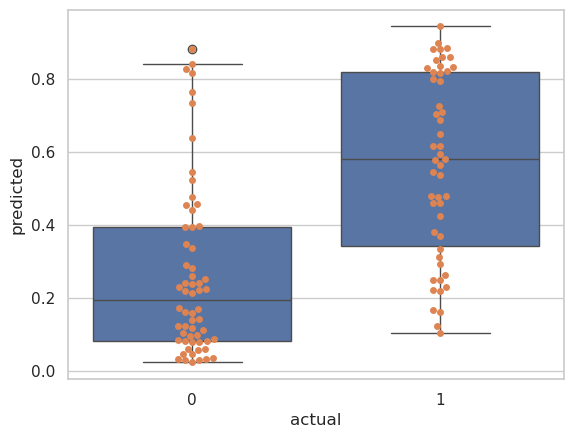

In [ ]:
sns.boxplot(pd.DataFrame({'actual': actual_relapse, 'predicted': pred_relapse}), x='actual', y='predicted')
sns.swarmplot(pd.DataFrame({'actual': actual_relapse, 'predicted': pred_relapse}), x='actual', y='predicted')
plt.savefig('Figure6b_left.svg')

In [156]:
actual_relapse.shape

(110, 98)

In [157]:
from sklearn.metrics import auc, precision_recall_curve

In [151]:
mat = sklearn.metrics.confusion_matrix(np.array(actual_relapse), np.array(pred_relapse) > 0.5)/54.0
print(sklearn.metrics.average_precision_score(np.array(actual_relapse), np.array(pred_relapse) > 0.5))
print(sklearn.metrics.precision_score(np.array(actual_relapse), np.array(pred_relapse) > 0.5))
print(sklearn.metrics.f1_score(np.array(actual_relapse), np.array(pred_relapse) > 0.5))
print(sklearn.metrics.roc_auc_score(np.array(actual_relapse), np.array(pred_relapse) > 0.5))

precision1, recall1, thresholds1 = precision_recall_curve(np.array(actual_relapse), np.array(pred_relapse) > 0.5)
plt.plot(1-recall1, precision1)
plt.xlim(0, 1.1)
plt.ylim(0, 1.1)
plt.show()
print(auc(recall1, precision1))

sns.heatmap(pd.DataFrame(mat, index=["Relapse", "No-Relapse"], columns=["Pred Relapse", "Pred No-Relapse"]), cmap='viridis')
#plt.savefig('confusion.svg')

ValueError: multilabel-indicator is not supported

### Vary the cutoff and find optimal point

In [168]:
actual_relapse, pred_relapse, thresholds = [], [], []

for pat in adata.obs['patient_id'].unique()[~adata.obs['patient_id'].unique().isin(trainIds)]:
    print(pat)

    ars, prs, threshes = [], [], []
    
    #print(list(set(adata.obs['patient_id']))[pat])
    normadata = adata.copy()
    normadata = normadata[normadata.obs['patient_id'] == pat]
    
    #print("Remember, A score of 1 is Relapse")
    #print("Actual Relapse: ", "No Relapse" if adata[adata.obs['patient_id'] == list(set(adata.obs['patient_id']))[pat]].obs.OR.iloc[0] == 0 else "Relapse")
    #print("Predicted Relapse: ", normadata.obs['predictions'].mean())
    
    resp = adata[adata.obs['patient_id'] == pat].obs.OR.iloc[0]

    for cutoff in np.arange(0.02, 0.99, 0.01):
        preds = normadata.obs['predictions'].copy()
    
        ars.append(resp)

        preds[preds <  cutoff] = 0.0
        preds[preds >= cutoff] = 1.0

        prs.append(preds.mean())

    actual_relapse.append(ars)
    pred_relapse.append(prs)
    thresholds.append(np.arange(0.02, 0.99, 0.01))



TMA_A_A1
TMA_A_A3
TMA_A_A4
TMA_A_A7
TMA_A_B2
TMA_A_B5
TMA_A_B6
TMA_A_C4
TMA_A_C5
TMA_A_D1
TMA_A_D6
TMA_A_D7
TMA_A_E1
TMA_A_E3
TMA_A_E5
TMA_A_F4
TMA_A_F6
TMA_A_F7
TMA_A_G1
TMA_A_G3
TMA_A_G4
TMA_A_H2
TMA_A_H5
TMA_A_H6
TMA_A_H7
TMA_A_I2
TMA_A_I3
TMA_A_I4
TMA_A_I5
TMA_A_I6
TMA_A_J7
TMA_B_A8
TMA_B_B1
TMA_B_B2
TMA_B_B6
TMA_B_C1
TMA_B_C2
TMA_B_C6
TMA_B_C8
TMA_B_D3
TMA_B_D7
TMA_B_E2
TMA_B_E3
TMA_B_E4
TMA_B_E8
TMA_B_F5
TMA_B_G4
TMA_B_G7
TMA_B_H5
TMA_B_H6
TMA_B_I7
TMA_B_J2
TMA_B_J3
TMA_B_J4
TMA_B_J8


In [169]:
actual_relapse, pred_relapse, thresholds = np.array(actual_relapse), np.array(pred_relapse), np.array(thresholds)

Prec, F1, AUC, PRAUC = [], [], [], []
for cutoff in np.arange(0.02, 0.99, 0.01):
    #print(sklearn.metrics.average_precision_score(actual_relapse, pred_relapse < 0.5))
    #print(sklearn.metrics.precision_score(actual_relapse, pred_relapse < 0.5))
    #print(sklearn.metrics.f1_score(actual_relapse, pred_relapse < 0.5))
    #print(sklearn.metrics.roc_auc_score(actual_relapse, pred_relapse < 0.5))

    Prec.append(sklearn.metrics.precision_score(actual_relapse[thresholds == cutoff], pred_relapse[thresholds == cutoff] > 0.5))
    F1.append(sklearn.metrics.f1_score(actual_relapse[thresholds == cutoff], pred_relapse[thresholds == cutoff] > 0.5))
    AUC.append(sklearn.metrics.roc_auc_score(actual_relapse[thresholds == cutoff], pred_relapse[thresholds == cutoff] > 0.5))
    
    precision1, recall1, thresholds1 = precision_recall_curve(actual_relapse[thresholds == cutoff], pred_relapse[thresholds == cutoff] > 0.5)
    #print(auc(recall1, precision1))
    PRAUC.append(auc(recall1, precision1))

/home/akilgall/miniconda3/envs/dgl_cuda_cox_new/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/akilgall/miniconda3/envs/dgl_cuda_cox_new/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/akilgall/miniconda3/envs/dgl_cuda_cox_new/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

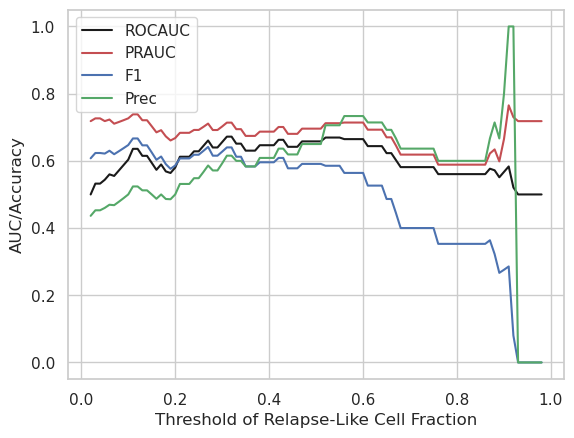

In [ ]:
plt.plot(np.arange(0.02, 0.99, 0.01), AUC, 'k-', label='ROCAUC')
plt.plot(np.arange(0.02, 0.99, 0.01), PRAUC, 'r-', label='PRAUC')
plt.plot(np.arange(0.02, 0.99, 0.01), F1, 'b-', label='F1')
plt.plot(np.arange(0.02, 0.99, 0.01), Prec, 'g-', label='Prec')
plt.xlabel("Threshold of Relapse-Like Cell Fraction")
plt.ylabel("AUC/Accuracy")
plt.legend()
plt.savefig('Figure7b_right.svg')